# NYC 311 Heating Resolution Time: Audited Cleaning, EDA, and ML Preparation

**Research question:** Can information available at the exact moment a NYC 311 heating request is created predict how many hours it will take to close?

This revised notebook uses all rows and all columns in the supplied NYC 311 file. The 15 GB raw CSV is scanned in chunks of 500,000 rows for macro-level EDA and heating extraction; the complete heating subset is then loaded for cleaning and predictor-focused EDA. The cleaning sequence was informed by the supplied `heating_eda.ipynb`, but every count and decision below is recalculated from this project file rather than copied from the reference.

The notebook explicitly audits and removes duplicates, tests redundancy, normalizes placeholder missing values, applies a documented missingness rule, physically constructs the final modeling DataFrame, and asserts that the decision table agrees with the executed transformations.

## Course EDA and visualization rules applied

The notebook operationalizes the guidance in all supplied course references, with `DATA230_Lecture2_Matplotlib.pdf` and `DATA230_Lecture3_SeabornPlotly.pdf` governing chart construction and `DATA230_Lecture4_EDA.pdf` and `DATA230_Lecture5_EDAAdv.pdf` governing EDA decisions:

- Follow the sequence **Structure -> Clean -> Univariate -> Bivariate -> Multivariate -> Decisions**.
- State the exact question answered by every figure before choosing its chart type.
- Audit types, units, missingness, impossible values, identifiers, duplicates, redundancy, outliers, and leakage before modeling.
- Detect string placeholders and impossible legal values because `isna()` alone cannot see them.
- Drop a missing target rather than inventing it; use median imputation for skewed predictors and fit imputation only on training data.
- Treat over 30% missing as a candidate for column removal, with domain reasoning recorded.
- Show important cleaning transformations before and after.
- For amounts, sort bars by value and use horizontal orientation for long labels; use heatmaps for grids larger than roughly 5 x 5.
- For distributions, use honest bin widths, quantiles/box summaries, and QQ evidence; do not use an unconstrained KDE that invents impossible negative hours.
- For bivariate analysis, use scatter for numeric-numeric, distribution/summary comparisons for numeric-categorical, and heatmaps or grouped/stacked bars for categorical-categorical.
- Count each group before comparing it, exclude weak-support estimates from ranked displays, and show uncertainty where practical.
- Use a diverging correlation palette centered at zero.
- Use chronological x-axes for time series, connect observations in time order, use markers, and distinguish multiple lines with both color and dash pattern rather than color alone.
- Finish with the three-column decision table: **Column / issue**, **Decision**, and **Because**.
- Use the Matplotlib Axes API for precise static comparisons, Seaborn for DataFrame-aware statistical summaries and annotated heatmaps, and Plotly only where interaction materially improves geographic or high-detail inspection.
- Use explicit figure sizes and DPI, readable axis labels with units, light grids only where useful, colorblind-safe categorical colors, and line styles plus markers whenever multiple time series must remain distinguishable without color.

## 0. Setup and source validation

In [37]:
from pathlib import Path
from collections import Counter
import gc
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 180)

PLOT_TEMPLATE = "plotly_white"
LINE_WIDTH = 2.4
MARKER_SIZE = 6
BOROUGH_ORDER = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
BOROUGH_COLORS = dict(zip(BOROUGH_ORDER, sns.color_palette("colorblind", n_colors=5).as_hex()))
LINE_STYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titleweight": "semibold",
})

DATA_DIR = Path(".")
RAW_CSV = Path(os.environ.get(
    "NYC311_CSV",
    DATA_DIR / "311_Service_Requests_from_2020_to_Present_20261003.csv",
))
HEATING_CACHE = DATA_DIR / "nyc311_heating_hot_water_all_columns_v2.csv"
CHUNK_SIZE = 500_000
NYC_DATE_FORMAT = "%m/%d/%Y %I:%M:%S %p"

PROBLEM = "Problem (formerly Complaint Type)"
DETAIL = "Problem Detail (formerly Descriptor)"
ADDITIONAL = "Additional Details"
CREATED = "Created Date"
CLOSED = "Closed Date"
BOROUGH = "Borough"
STATUS = "Status"

assert RAW_CSV.exists(), f"Raw CSV not found: {RAW_CSV.resolve()}"
header = pd.read_csv(RAW_CSV, nrows=0).columns.tolist()
required = {PROBLEM, DETAIL, CREATED, CLOSED, BOROUGH, STATUS}
assert required.issubset(header), f"Missing required columns: {sorted(required - set(header))}"
print(f"Raw file: {RAW_CSV.resolve()}")
print(f"Raw size: {RAW_CSV.stat().st_size / 1024**3:,.2f} GiB")
print(f"Source columns: {len(header)}")

Raw file: /Users/gowtham/Documents/Ragavi/MS/230_DV/Project/Project1/311_Service_Requests_from_2020_to_Present_20261003.csv
Raw size: 14.86 GiB
Source columns: 44


## 1. Macro-level EDA across the complete 311 dataset

The loop updates bounded counters rather than appending raw chunks. Every matching heating/hot-water row is written directly to a cache with all original columns.

In [38]:
problem_counts = Counter()
problem_borough_counts = Counter()
problem_borough_year_counts = Counter()
total_rows = 0
heating_rows_written = 0
first_write = True
heating_pattern = r"(?:\bHEAT(?:ING)?\b|\bHOT\s*WATER\b)"

for chunk_no, chunk in enumerate(
    pd.read_csv(RAW_CSV, chunksize=CHUNK_SIZE, low_memory=False), start=1
):
    total_rows += len(chunk)
    problem = chunk[PROBLEM].fillna("UNKNOWN").astype("string").str.strip()
    borough = chunk[BOROUGH].fillna("UNKNOWN").astype("string").str.strip()
    year = pd.to_datetime(chunk[CREATED], format=NYC_DATE_FORMAT, errors="coerce").dt.year.astype("Int64").astype("string")

    problem_counts.update(problem.value_counts(dropna=False).to_dict())
    pb = pd.DataFrame({"problem": problem, "borough": borough}).groupby(["problem", "borough"], dropna=False).size()
    problem_borough_counts.update({tuple(k): int(v) for k, v in pb.items()})
    pby = pd.DataFrame({"problem": problem, "borough": borough, "year": year}).groupby(
        ["problem", "borough", "year"], dropna=False
    ).size()
    problem_borough_year_counts.update({tuple(k): int(v) for k, v in pby.items()})

    heat_mask = problem.str.contains(heating_pattern, case=False, regex=True, na=False)
    heat_chunk = chunk.loc[heat_mask]
    if not heat_chunk.empty:
        heat_chunk.to_csv(HEATING_CACHE, mode="w" if first_write else "a", header=first_write, index=False)
        first_write = False
        heating_rows_written += len(heat_chunk)

    if chunk_no == 1 or chunk_no % 10 == 0:
        print(f"chunk={chunk_no:,} | all rows={total_rows:,} | heating rows={heating_rows_written:,}")
    del chunk, heat_chunk
    gc.collect()

assert heating_rows_written > 0
print(f"Finished: {total_rows:,} total rows and {heating_rows_written:,} heating rows.")

chunk=1 | all rows=500,000 | heating rows=6,964
chunk=10 | all rows=5,000,000 | heating rows=371,853
chunk=20 | all rows=10,000,000 | heating rows=783,196
chunk=30 | all rows=15,000,000 | heating rows=1,154,503
chunk=40 | all rows=20,000,000 | heating rows=1,537,076
Finished: 22,671,531 total rows and 1,663,150 heating rows.


In [39]:
top20 = pd.Series(problem_counts, name="count").sort_values(ascending=False).head(20)
top10 = top20.head(10).index
top5 = top20.head(5).index
valid_boroughs = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]
pb_long = pd.DataFrame([(p, b, n) for (p, b), n in problem_borough_counts.items()], columns=[PROBLEM, BOROUGH, "count"])
pby_long = pd.DataFrame([(p, b, y, n) for (p, b, y), n in problem_borough_year_counts.items()], columns=[PROBLEM, BOROUGH, "year", "count"])

findfont: Failed to find font weight semibold, now using 700.


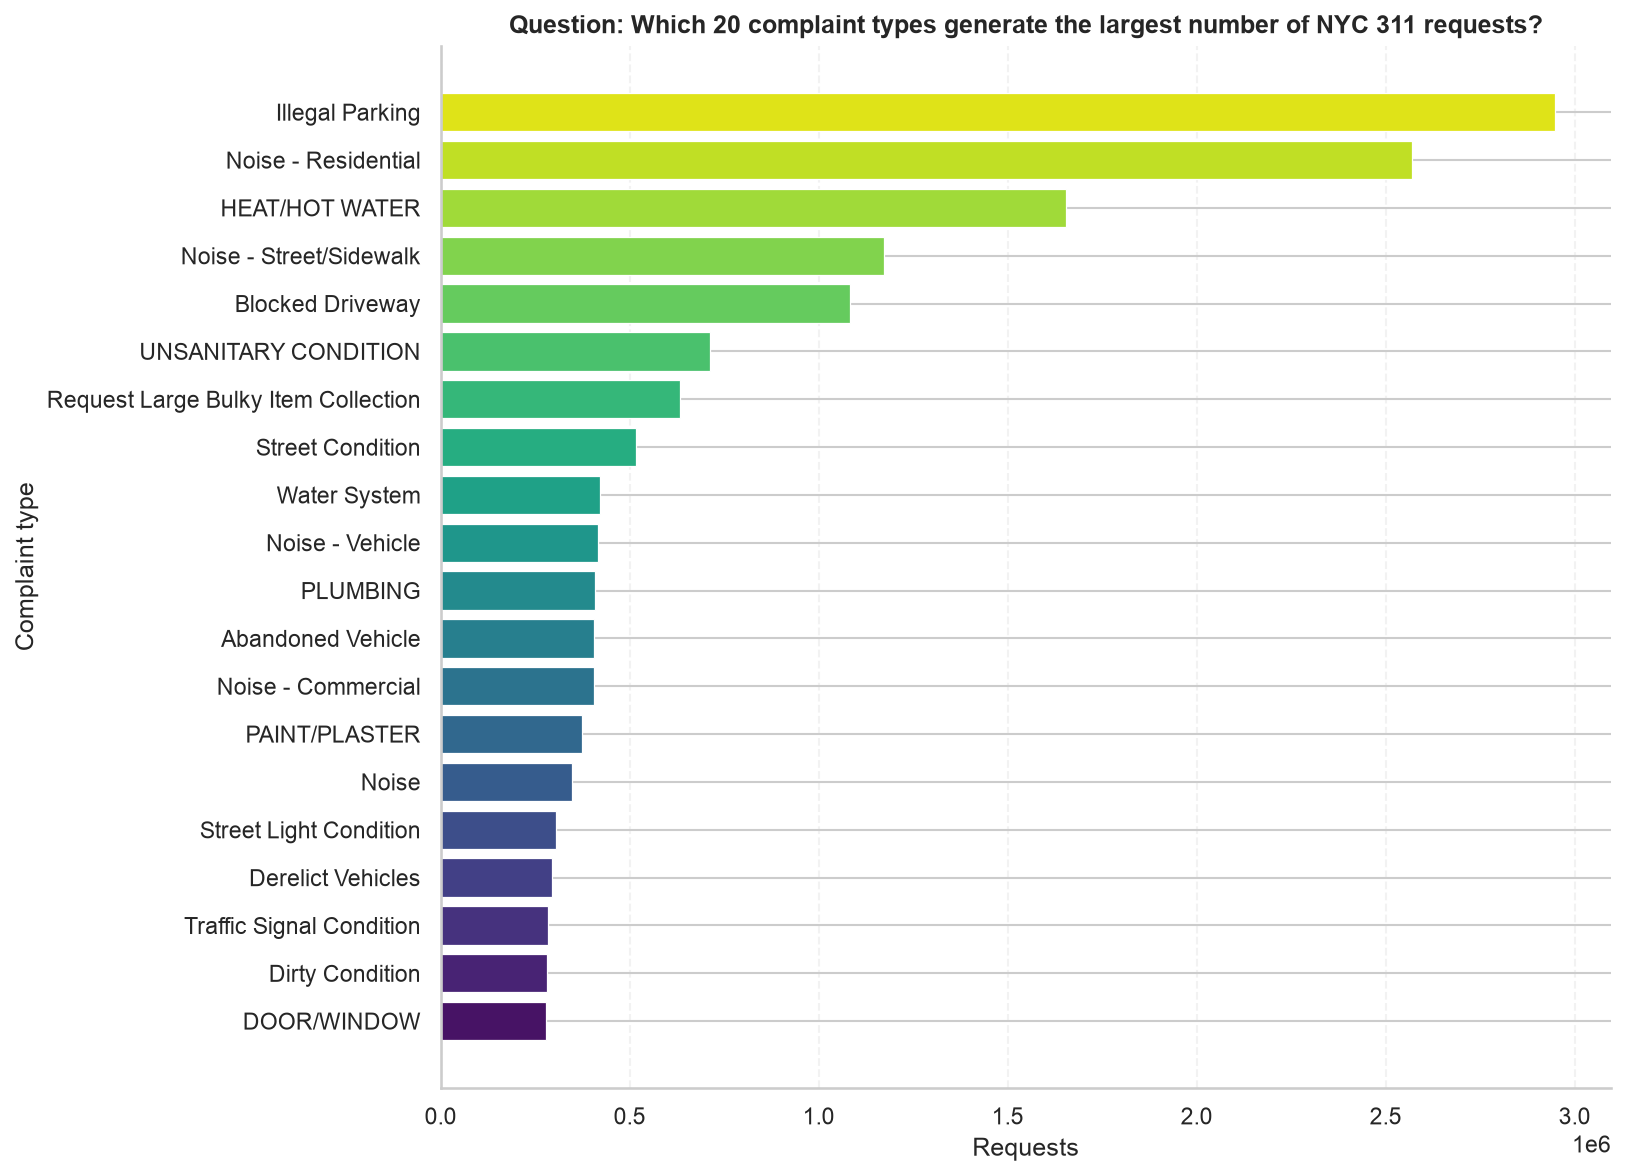

In [40]:
question = "Question: Which 20 complaint types generate the largest number of NYC 311 requests?"
top20_plot = top20.sort_values().rename_axis(PROBLEM).reset_index()
fig, ax = plt.subplots(figsize=(11, 8), dpi=150)
colors = sns.color_palette("viridis", n_colors=len(top20_plot))
ax.barh(top20_plot[PROBLEM], top20_plot["count"], color=colors, edgecolor="white", linewidth=0.6)
ax.set(title=question, xlabel="Requests", ylabel="Complaint type")
ax.grid(axis="x", alpha=0.25, linestyle="--")
fig.tight_layout()
plt.show()

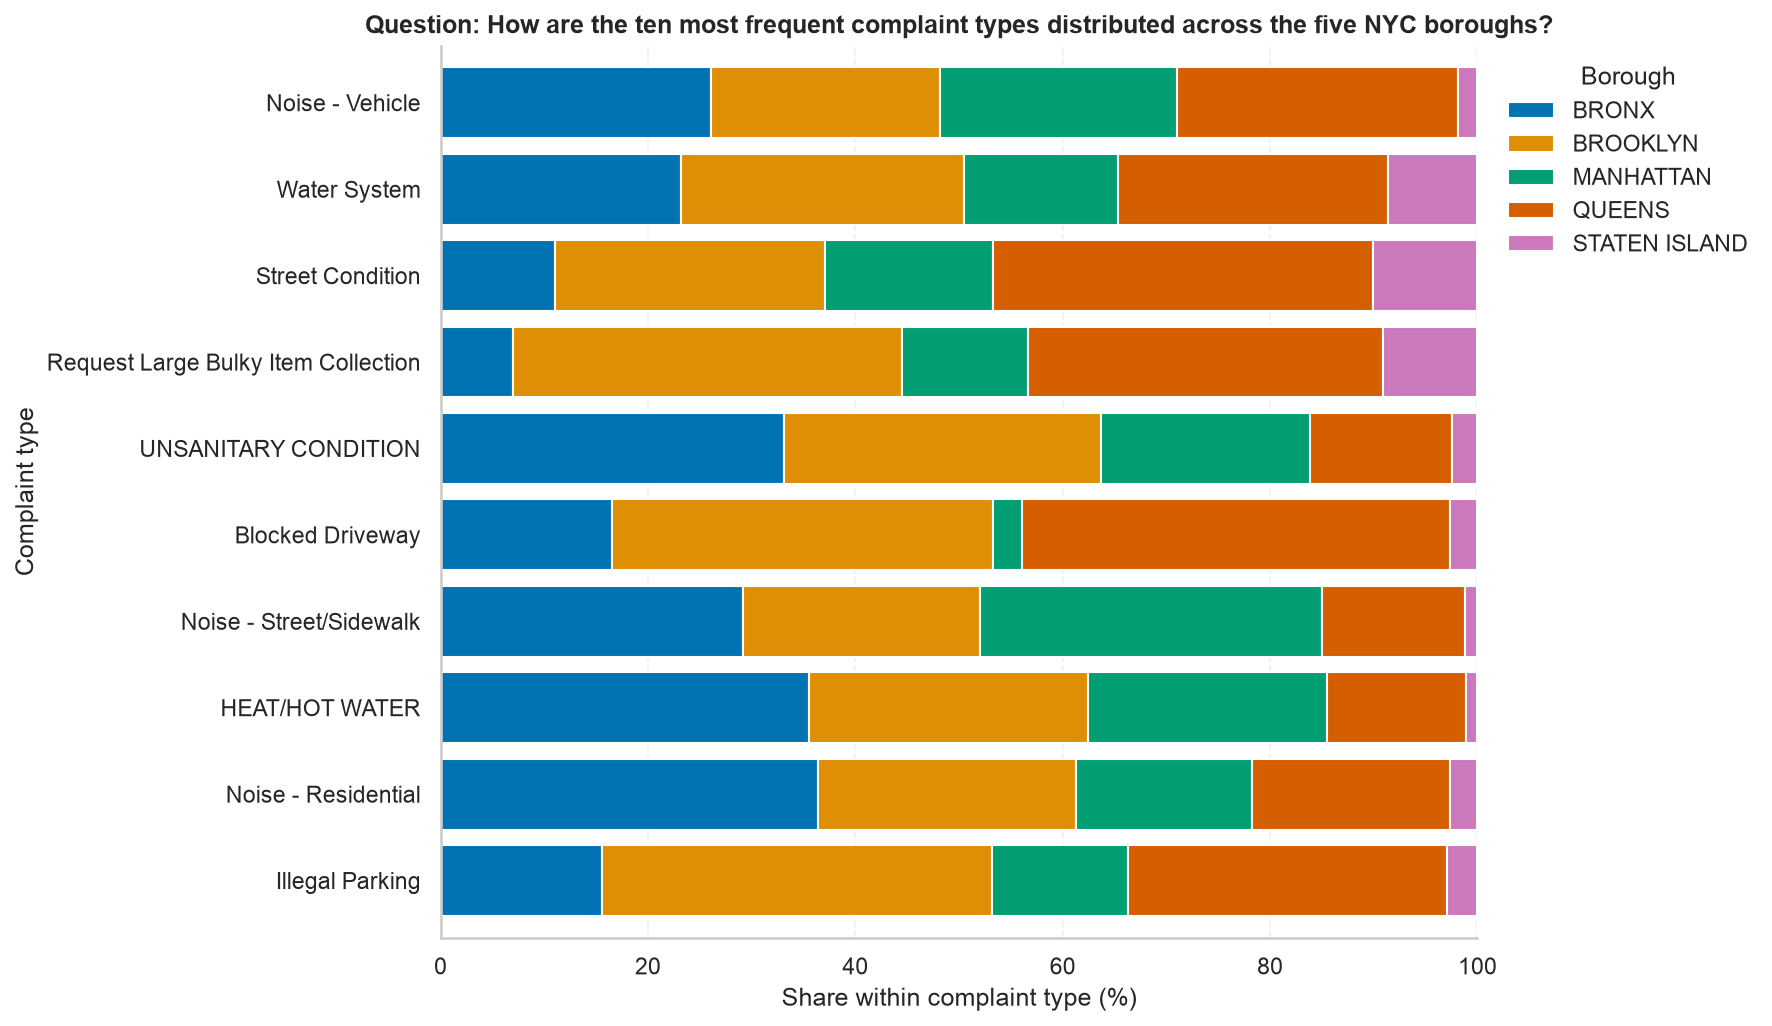

In [41]:
question = "Question: How are the ten most frequent complaint types distributed across the five NYC boroughs?"
top10_borough = (
    pb_long[pb_long[PROBLEM].isin(top10) & pb_long[BOROUGH].isin(valid_boroughs)]
    .pivot_table(index=PROBLEM, columns=BOROUGH, values="count", aggfunc="sum", fill_value=0)
    .reindex(index=top10, columns=valid_boroughs, fill_value=0).dropna(how="all")
)
top10_share = top10_borough.div(top10_borough.sum(axis=1).replace(0, np.nan), axis=0).mul(100).dropna(how="all")
top10_share.index.name = PROBLEM
fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
top10_share.loc[:, valid_boroughs].plot.barh(stacked=True, ax=ax, color=[BOROUGH_COLORS[b] for b in valid_boroughs], width=0.82)
ax.set(title=question, xlabel="Share within complaint type (%)", ylabel="Complaint type", xlim=(0, 100))
ax.legend(title="Borough", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
ax.grid(axis="x", alpha=0.25, linestyle="--")
fig.tight_layout()
plt.show()

findfont: Failed to find font weight semibold, now using 700.


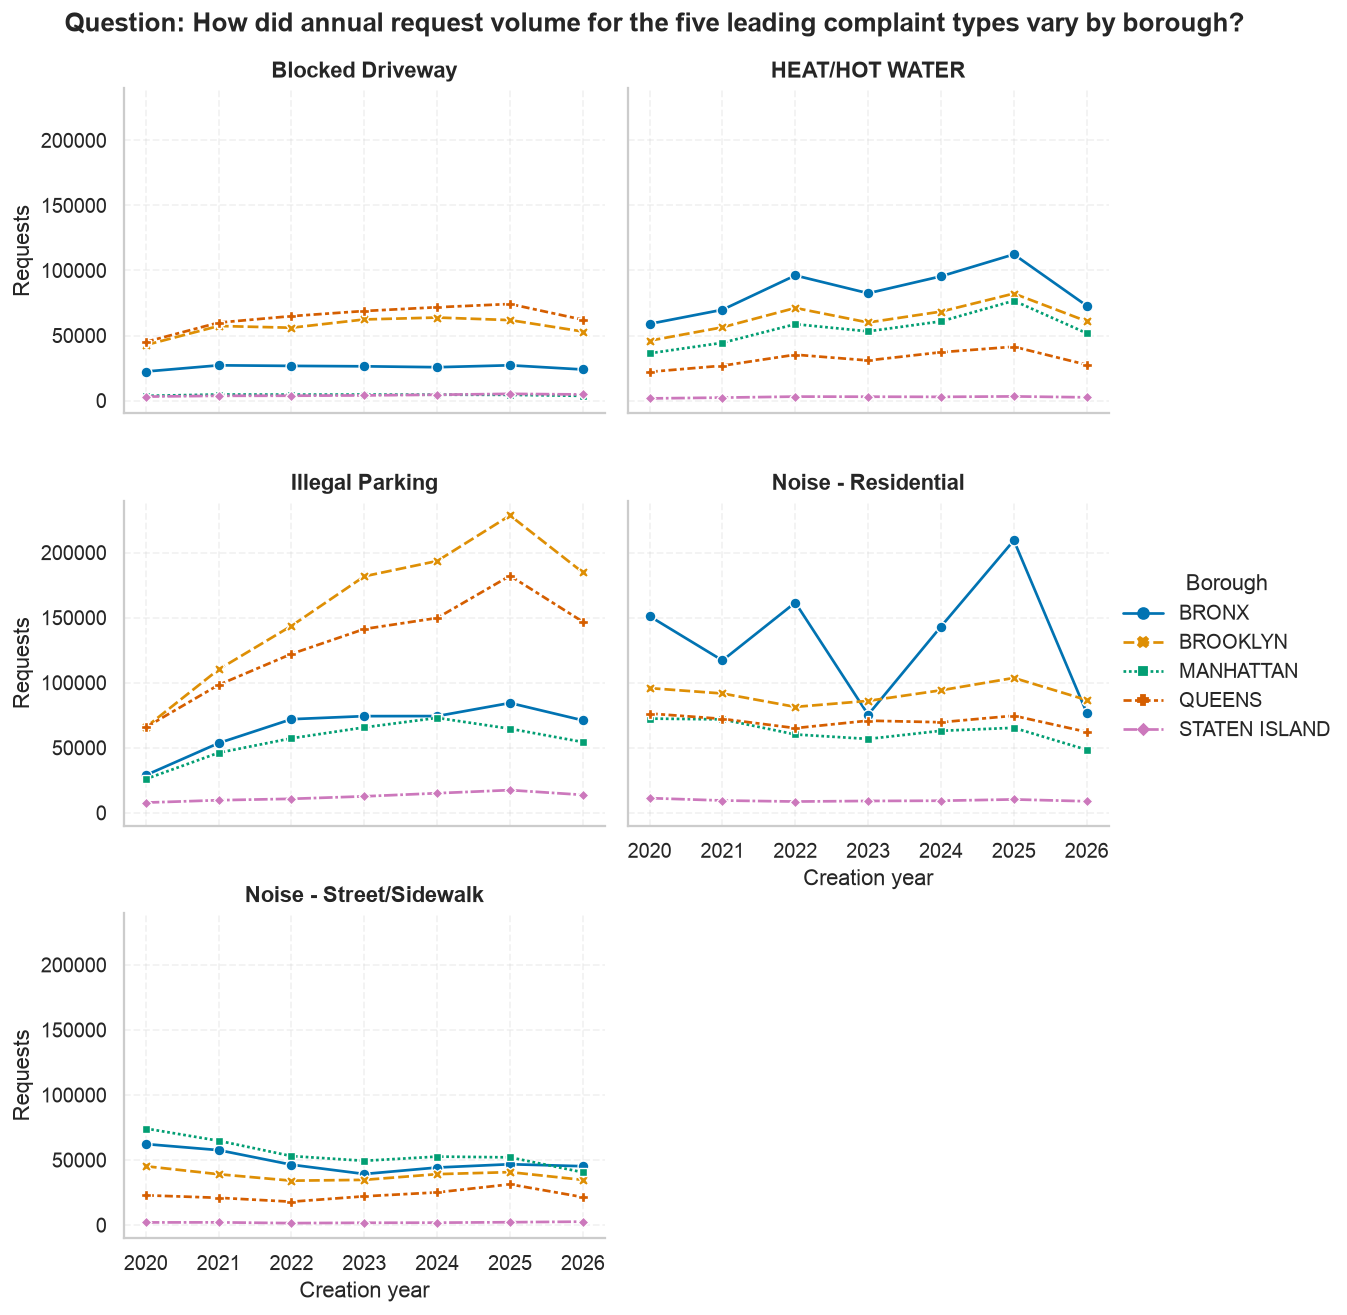

In [42]:
question = "Question: How did annual request volume for the five leading complaint types vary by borough?"
macro_multi = pby_long[
    pby_long[PROBLEM].isin(top5) & pby_long[BOROUGH].isin(valid_boroughs)
    & pby_long["year"].str.fullmatch(r"\d{4}", na=False)
].copy()
macro_multi["year"] = pd.to_numeric(macro_multi["year"], errors="coerce")
macro_multi = macro_multi.dropna(subset=["year", "count"])
assert not macro_multi.empty
grid = sns.relplot(
    data=macro_multi, x="year", y="count", hue=BOROUGH, style=BOROUGH, col=PROBLEM,
    col_wrap=2, kind="line", markers=True, dashes=True, palette=BOROUGH_COLORS,
    hue_order=valid_boroughs, style_order=valid_boroughs, height=3.3, aspect=1.35,
)
grid.set_axis_labels("Creation year", "Requests")
grid.set_titles("{col_name}")
grid.figure.suptitle(question, y=1.02, fontweight="semibold")
for ax in grid.axes.flat:
    ax.grid(alpha=0.25, linestyle="--")
plt.show()

## 2. Heating-only structural audit and cleaning

In [43]:
heating_raw = pd.read_csv(HEATING_CACHE, low_memory=False)
assert len(heating_raw) == heating_rows_written
assert heating_raw.columns.tolist() == header
print(f"Heating subset before cleaning: {heating_raw.shape[0]:,} rows x {heating_raw.shape[1]} columns")
display(heating_raw.head())

Heating subset before cleaning: 1,663,150 rows x 44 columns


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,Incident Address,Street Name,Cross Street 1,Cross Street 2,Intersection Street 1,Intersection Street 2,Address Type,City,Landmark,Facility Type,Status,Due Date,Resolution Description,Resolution Action Updated Date,Community Board,Council District,Police Precinct,BBL,Borough,X Coordinate (State Plane),Y Coordinate (State Plane),Open Data Channel Type,Park Facility Name,Park Borough,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,70607308,10/01/2026 11:58:54 PM,NaN,HPD,Department of Housing Preservation and Development,HEAT/HOT WATER,APARTMENT ONLY,NO HOT WATER,RESIDENTIAL BUILDING,10467.0,3327 DECATUR AVENUE,DECATUR AVENUE,NaN,NaN,NaN,NaN,ADDRESS,BRONX,NaN,NaN,Open,NaN,The following complaint conditions are still open. HPD has already attempted to notify the property owner that the condition exists; the tenant should provide access for the ow...,10/01/2026 12:00:00 AM,07 BRONX,11.0,Precinct 52,2.033520e+09,BRONX,"1,019,332","258,860",PHONE,Unspecified,BRONX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.877115,-73.873141,POINT (-73.873141377875 40.877115480725)
1,70615467,10/01/2026 11:41:10 PM,NaN,HPD,Department of Housing Preservation and Development,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11355.0,132-45 MAPLE AVENUE,MAPLE AVENUE,NaN,NaN,NaN,NaN,ADDRESS,FLUSHING,NaN,NaN,Open,NaN,The following complaint conditions are still open. HPD has already attempted to notify the property owner that the condition exists; the tenant should provide access for the ow...,10/01/2026 12:00:00 AM,07 QUEENS,20.0,Precinct 109,4.051010e+09,QUEENS,"1,030,954","214,110",ONLINE,Unspecified,QUEENS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.754236,-73.831427,POINT (-73.831427022953 40.754235662982)
2,70613895,10/01/2026 11:31:41 PM,NaN,HPD,Department of Housing Preservation and Development,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,10019.0,425 WEST 57 STREET,WEST 57 STREET,NaN,NaN,NaN,NaN,ADDRESS,NEW YORK,NaN,NaN,Open,NaN,The following complaint conditions are still open. HPD has already attempted to notify the property owner that the condition exists; the tenant should provide access for the ow...,10/01/2026 12:00:00 AM,04 MANHATTAN,6.0,Precinct 18,1.010670e+09,MANHATTAN,"987,955","219,193",ONLINE,Unspecified,MANHATTAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.768310,-73.986624,POINT (-73.986624390128 40.76830976173)
3,70608878,10/01/2026 11:31:30 PM,NaN,HPD,Department of Housing Preservation and Development,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11226.0,552 PARKSIDE AVENUE,PARKSIDE AVENUE,NaN,NaN,NaN,NaN,ADDRESS,BROOKLYN,NaN,NaN,Open,NaN,The following complaint conditions are still open. HPD has already attempted to notify the property owner that the condition exists; the tenant should provide access for the ow...,10/01/2026 12:00:00 AM,09 BROOKLYN,40.0,Precinct 71,3.050560e+09,BROOKLYN,"996,762","178,263",MOBILE,Unspecified,BROOKLYN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.655959,-73.954906,POINT (-73.954905860019 40.655958608083)
4,70608877,10/01/2026 11:26:06 PM,NaN,HPD,Department of Housing Preservation and Development,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,10032.0,76 ST NICHOLAS PLACE,ST NICHOLAS PLACE,NaN,NaN,NaN,NaN,ADDRESS,NEW YORK,NaN,NaN,Open,NaN,"This complaint is a duplicate of a building-wide condition already reported by another tenant. The original complaint is still open, and HPD may only need to confirm that the ...",10/01/2026 12:00:00 AM,09 MANHATTAN,9.0,Precinct 30,1.020540e+09,MANHATTAN,"1,000,634","241,478",MOBILE,Unspecified,MANHATTAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.829462,-73.940797,POINT (-73.940796918633 40.829461589532)


### 2.1 Normalize documented placeholder strings

Blank strings and exact labels such as `UNSPECIFIED`, `UNKNOWN`, `N/A`, `NULL`, and `NONE` are missing values, not categories. Conversion happens before missingness and redundancy calculations so the reported rates are honest.

In [44]:
heating = heating_raw.copy()
PLACEHOLDERS = {"", "UNSPECIFIED", "UNKNOWN", "N/A", "NA", "NULL", "NONE"}
placeholder_rows = []

missing_raw_percent = heating.isna().mean().mul(100).rename("before_placeholder_normalization")

for col in heating.select_dtypes(include=["object", "string"]).columns:
    text = heating[col].astype("string").str.strip()
    mask = text.str.upper().isin(PLACEHOLDERS)
    count = int(mask.sum())
    if count:
        placeholder_rows.append({"column": col, "converted_to_NaN": count})
        text = text.mask(mask, pd.NA)
    heating[col] = text

placeholder_audit = pd.DataFrame(placeholder_rows).sort_values("converted_to_NaN", ascending=False)
missing_after_placeholder_percent = heating.isna().mean().mul(100).rename("after_placeholder_normalization")
placeholder_missing_comparison = pd.concat(
    [missing_raw_percent, missing_after_placeholder_percent], axis=1
).sort_values("after_placeholder_normalization", ascending=False)
display(placeholder_audit)
display(placeholder_missing_comparison.round(3))

,column,converted_to_NaN
3,Park Facility Name,1663150
1,Police Precinct,2251
2,Borough,6
4,Park Borough,6
0,Status,2


,before_placeholder_normalization,after_placeholder_normalization
Park Facility Name,0.000,100.000
Taxi Pick Up Location,100.000,100.000
Vehicle Type,100.000,100.000
Taxi Company Borough,100.000,100.000
Due Date,100.000,100.000
Bridge Highway Segment,100.000,100.000
Road Ramp,100.000,100.000
Bridge Highway Direction,100.000,100.000
Facility Type,100.000,100.000
Bridge Highway Name,100.000,100.000


In [45]:
question = "Question: How much did placeholder normalization change the measured missingness of each affected column?"
missing_change_plot = (
    placeholder_missing_comparison
    .assign(change=lambda frame: frame["after_placeholder_normalization"] - frame["before_placeholder_normalization"])
    .query("change > 0")
    .sort_values("after_placeholder_normalization")
    .reset_index(names="column")
    .melt(id_vars=["column", "change"], value_vars=["before_placeholder_normalization", "after_placeholder_normalization"],
          var_name="stage", value_name="missing_percent")
)
if missing_change_plot.empty:
    print("No documented placeholder strings changed measured missingness.")
else:
    fig = px.bar(
        missing_change_plot, x="missing_percent", y="column", color="stage", orientation="h", barmode="group",
        labels={"missing_percent": "Missing values (%)", "column": "Column", "stage": "Measurement stage"},
        title=question,
        color_discrete_map={"before_placeholder_normalization": "#9ecae1", "after_placeholder_normalization": "#de2d26"},
    )
    fig.update_layout(template=PLOT_TEMPLATE, legend_title_text="Stage")
    fig.show()

### 2.2 Parse dates and numeric coordinates

ZIP codes, BBLs, districts, boards, and precincts remain labels. Latitude and longitude are measurements and are converted to numeric.

In [46]:
def parse_nyc_datetime(series):
    parsed = pd.to_datetime(series, format=NYC_DATE_FORMAT, errors="coerce")
    fallback = parsed.isna() & series.notna()
    if fallback.any():
        parsed.loc[fallback] = pd.to_datetime(series.loc[fallback], errors="coerce")
    return parsed

heating["created_dt"] = parse_nyc_datetime(heating[CREATED])
heating["closed_dt"] = parse_nyc_datetime(heating[CLOSED])
for col in ["Latitude", "Longitude", "X Coordinate (State Plane)", "Y Coordinate (State Plane)"]:
    heating[col] = pd.to_numeric(heating[col].astype("string").str.replace(",", "", regex=False), errors="coerce")

for col in [PROBLEM, DETAIL, ADDITIONAL, BOROUGH, "Open Data Channel Type", "Location Type", "Address Type", "City"]:
    if col in heating:
        heating[col] = heating[col].astype("string").str.strip().str.upper()

### 2.3 Audit and remove exact duplicate requests

`Unique Key` is excluded from the comparison because it assigns a different identifier to every row and would hide otherwise identical requests. All other original fields participate in the exact-duplicate test.

In [47]:
duplicate_subset = [c for c in header if c != "Unique Key"]
rows_before_duplicates = len(heating)
duplicate_mask = heating.duplicated(subset=duplicate_subset, keep="first")
n_duplicates = int(duplicate_mask.sum())
heating = heating.loc[~duplicate_mask].reset_index(drop=True)

duplicate_audit = pd.DataFrame({
    "stage": ["before", "duplicates removed", "after"],
    "rows": [rows_before_duplicates, n_duplicates, len(heating)],
})
display(duplicate_audit)
assert len(heating) == rows_before_duplicates - n_duplicates
assert heating.duplicated(subset=duplicate_subset).sum() == 0

,stage,rows
0,before,1663150
1,duplicates removed,3128
2,after,1660022


### 2.4 Test exact and functional redundancy

In [48]:
redundancy_rows = []
exact_copy_drops = []
COPY_PAIRS = [
    ("Cross Street 1", "Intersection Street 1"),
    ("Cross Street 2", "Intersection Street 2"),
    (BOROUGH, "Park Borough"),
]
for retained, candidate in COPY_PAIRS:
    if retained in heating and candidate in heating:
        same = heating[retained].fillna("<MISSING>").eq(heating[candidate].fillna("<MISSING>"))
        redundancy_rows.append({
            "candidate": candidate, "compared_with": retained,
            "matching_rows": int(same.sum()), "total_rows": len(heating),
            "match_percent": 100 * same.mean(), "decision": "drop" if same.all() else "review",
        })
        if same.all():
            exact_copy_drops.append(candidate)

# Location is a text serialization of Longitude and Latitude; verify where all are present.
location_match = False
if {"Location", "Latitude", "Longitude"}.issubset(heating.columns):
    extracted = heating["Location"].astype("string").str.extract(r"POINT \(([-+0-9.eE]+) ([-+0-9.eE]+)\)")
    loc_lon = pd.to_numeric(extracted[0], errors="coerce")
    loc_lat = pd.to_numeric(extracted[1], errors="coerce")
    comparable = loc_lon.notna() & loc_lat.notna() & heating["Longitude"].notna() & heating["Latitude"].notna()
    max_error = max(
        float((loc_lon[comparable] - heating.loc[comparable, "Longitude"]).abs().max()) if comparable.any() else np.nan,
        float((loc_lat[comparable] - heating.loc[comparable, "Latitude"]).abs().max()) if comparable.any() else np.nan,
    )
    coordinate_missing = heating["Longitude"].isna() | heating["Latitude"].isna()
    location_missing_consistent = heating["Location"].isna().eq(coordinate_missing).all()
    location_match = bool(comparable.any() and max_error < 1e-8 and location_missing_consistent)
    redundancy_rows.append({
        "candidate": "Location", "compared_with": "Latitude + Longitude",
        "matching_rows": int(comparable.sum()), "total_rows": len(heating),
        "match_percent": 100 * comparable.mean(), "decision": "drop" if location_match else "review",
    })

redundancy_audit = pd.DataFrame(redundancy_rows)
display(redundancy_audit)

,candidate,compared_with,matching_rows,total_rows,match_percent,decision
0,Intersection Street 1,Cross Street 1,1660022,1660022,100.000000,drop
1,Intersection Street 2,Cross Street 2,1660022,1660022,100.000000,drop
2,Park Borough,Borough,1660022,1660022,100.000000,drop
3,Location,Latitude + Longitude,1659834,1660022,99.988675,drop


### 2.5 Audit constant, near-constant, and missing columns

In [49]:
constant_cols = [c for c in header if c in heating and heating[c].nunique(dropna=False) <= 1]
dominance_rows = []
near_constant_cols = []
for col in header:
    if col not in heating or col in constant_cols:
        continue
    counts = heating[col].value_counts(dropna=False)
    if len(counts):
        share = 100 * counts.iloc[0] / len(heating)
        dominance_rows.append({"column": col, "dominant_value": counts.index[0], "dominant_percent": share})
        if share >= 99.5:
            near_constant_cols.append(col)

dominance_audit = pd.DataFrame(dominance_rows).sort_values("dominant_percent", ascending=False)
print("Constant columns:", constant_cols)
display(dominance_audit.head(20))

MISSING_DROP_THRESHOLD = 30.0
missing_table_before = pd.DataFrame({
    "dtype": heating.dtypes.astype(str),
    "missing_rows": heating.isna().sum(),
    "missing_percent": heating.isna().mean().mul(100),
    "distinct_nonmissing": heating.nunique(dropna=True),
}).sort_values(["missing_percent", "distinct_nonmissing"], ascending=[False, True])
missing_table_before.index.name = "column"
display(missing_table_before.round({"missing_percent": 3}))

sparse_cols = missing_table_before.index[missing_table_before["missing_percent"] > MISSING_DROP_THRESHOLD].tolist()
print(f"Columns above {MISSING_DROP_THRESHOLD:.0f}% missing:", sparse_cols)

Constant columns: ['Facility Type', 'Due Date', 'Park Facility Name', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment']


,column,dominant_value,dominant_percent
16,Address Type,ADDRESS,99.994880
3,Agency,HPD,99.608620
4,Agency Name,Department of Housing Preservation and Development,99.608620
5,Problem (formerly Complaint Type),HEAT/HOT WATER,99.608620
13,Cross Street 2,<NA>,99.500669
15,Intersection Street 2,<NA>,99.500669
14,Intersection Street 1,<NA>,99.500248
12,Cross Street 1,<NA>,99.500248
18,Landmark,<NA>,99.499464
8,Location Type,RESIDENTIAL BUILDING,99.499344


,dtype,missing_rows,missing_percent,distinct_nonmissing
column,,,,
Facility Type,float64,1660022,100.000,0
Due Date,float64,1660022,100.000,0
Park Facility Name,string,1660022,100.000,0
Vehicle Type,float64,1660022,100.000,0
Taxi Company Borough,float64,1660022,100.000,0
Taxi Pick Up Location,float64,1660022,100.000,0
Bridge Highway Name,float64,1660022,100.000,0
Bridge Highway Direction,float64,1660022,100.000,0
Road Ramp,float64,1660022,100.000,0


Columns above 30% missing: ['Facility Type', 'Due Date', 'Park Facility Name', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment', 'Cross Street 2', 'Intersection Street 2', 'Cross Street 1', 'Intersection Street 1', 'Landmark']


### 2.6 Construct and clean the target with mutually exclusive row counts

Open requests cannot provide a supervised target; nonpositive durations are invalid; and the most extreme upper 0.5% of otherwise valid durations are removed using an explicit empirical rule.

In [50]:
heating["resolution_hours"] = (heating["closed_dt"] - heating["created_dt"]).dt.total_seconds() / 3600
raw_resolution = heating["resolution_hours"].copy()

row_reason = pd.Series("candidate", index=heating.index, dtype="string")
row_reason.loc[heating["created_dt"].isna()] = "invalid_or_missing_created_date"
row_reason.loc[row_reason.eq("candidate") & heating["closed_dt"].isna()] = "missing_closed_date_open_ticket"
row_reason.loc[row_reason.eq("candidate") & heating["resolution_hours"].le(0)] = "nonpositive_resolution_time"
valid_for_cutoff = row_reason.eq("candidate")
OUTLIER_QUANTILE = 0.995
upper_outlier_cutoff = heating.loc[valid_for_cutoff, "resolution_hours"].quantile(OUTLIER_QUANTILE)
row_reason.loc[valid_for_cutoff & heating["resolution_hours"].gt(upper_outlier_cutoff)] = "above_99_5_percentile"
row_reason.loc[row_reason.eq("candidate")] = "kept"

row_audit = row_reason.value_counts().rename_axis("row_disposition").to_frame("rows")
row_audit["percent_of_deduplicated_heating_rows"] = 100 * row_audit["rows"] / len(heating)
display(row_audit)
assert row_audit["rows"].sum() == len(heating)

heating_valid = heating.loc[row_reason.eq("kept")].copy()
print(f"Target upper cutoff: {upper_outlier_cutoff:,.2f} hours")
print(f"Valid-target rows retained: {len(heating_valid):,}")

,rows,percent_of_deduplicated_heating_rows
row_disposition,,
kept,1633865,98.424298
missing_closed_date_open_ticket,17655,1.06354
above_99_5_percentile,8211,0.494632
nonpositive_resolution_time,291,0.01753


Target upper cutoff: 252.52 hours
Valid-target rows retained: 1,633,865


In [51]:
question = "Question: How many heating records remain after duplicate removal and each mutually exclusive target-cleaning rule?"
invalid_created_n = int((row_reason == "invalid_or_missing_created_date").sum())
missing_closed_n = int((row_reason == "missing_closed_date_open_ticket").sum())
nonpositive_n = int((row_reason == "nonpositive_resolution_time").sum())
extreme_n = int((row_reason == "above_99_5_percentile").sum())
fig = go.Figure(go.Waterfall(
    orientation="v",
    measure=["absolute", "relative", "relative", "relative", "relative", "relative", "total"],
    x=["Heating rows", "Duplicates", "Invalid created", "Missing closed", "Nonpositive", "Extreme", "Final rows"],
    y=[len(heating_raw), -n_duplicates, -invalid_created_n, -missing_closed_n, -nonpositive_n, -extreme_n, 0],
    text=[f"{len(heating_raw):,}", f"-{n_duplicates:,}", f"-{invalid_created_n:,}", f"-{missing_closed_n:,}",
          f"-{nonpositive_n:,}", f"-{extreme_n:,}", f"{len(heating_valid):,}"],
    textposition="outside",
    connector={"line": {"color": "#7f7f7f", "width": 1}},
    decreasing={"marker": {"color": "#de2d26"}},
    increasing={"marker": {"color": "#31a354"}},
    totals={"marker": {"color": "#3182bd"}},
))
fig.update_layout(title=question, template=PLOT_TEMPLATE, yaxis_title="Rows", showlegend=False)
fig.show()

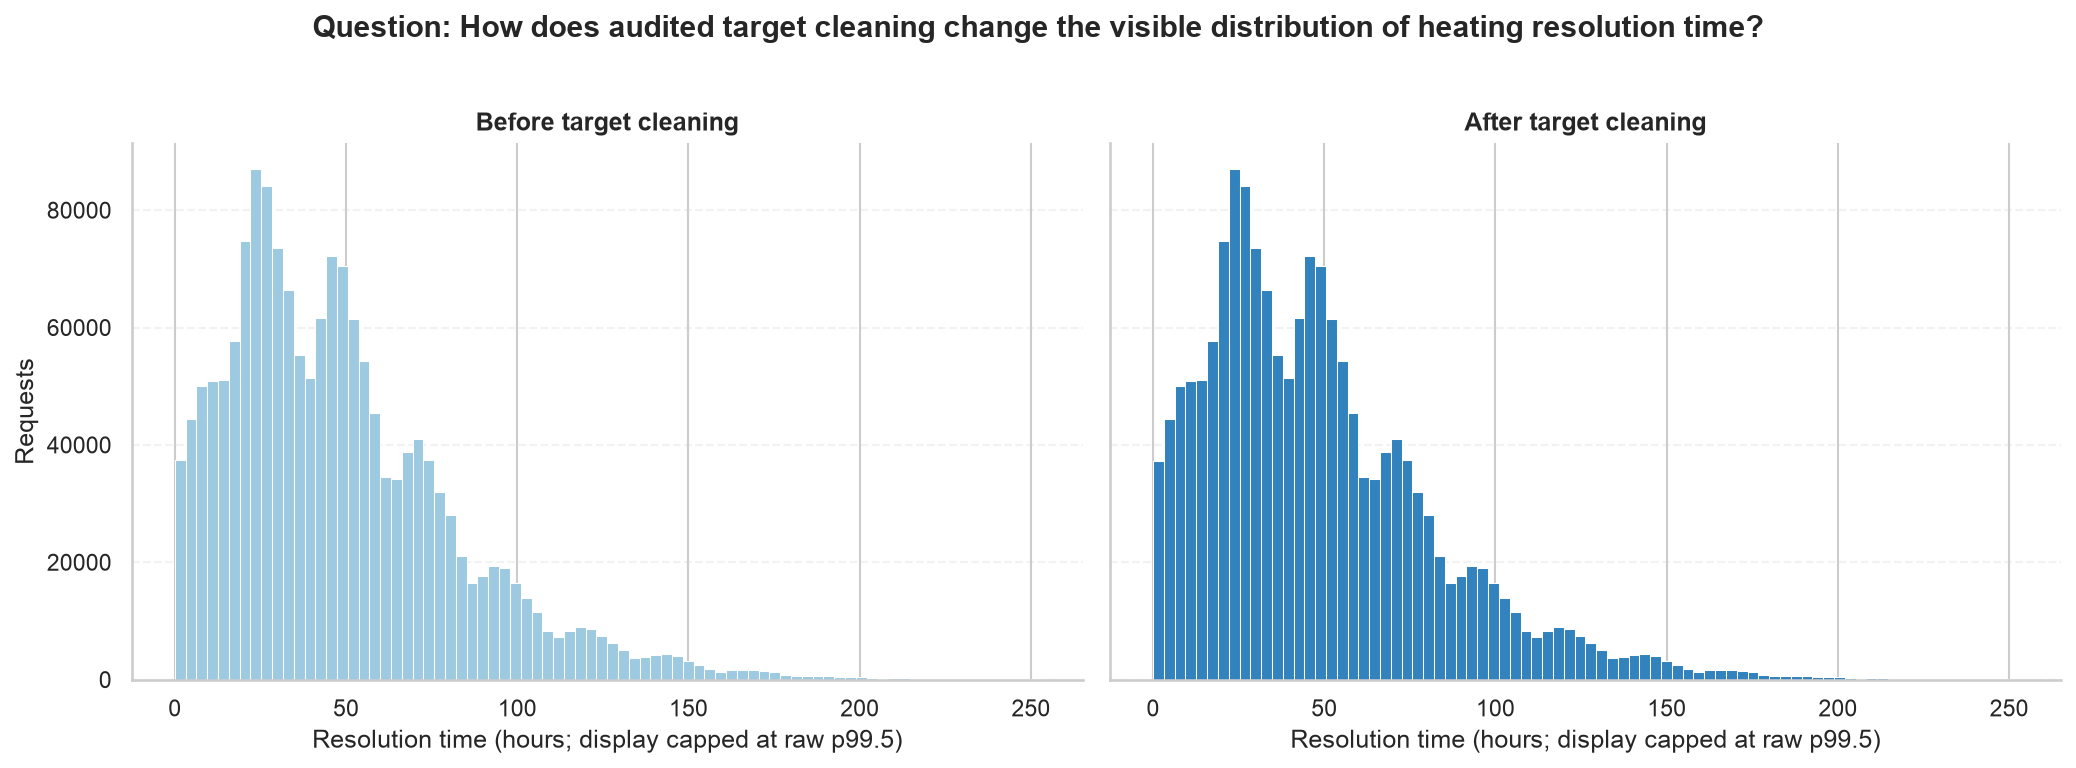

In [52]:
question = "Question: How does audited target cleaning change the visible distribution of heating resolution time?"
raw_plot = pd.to_numeric(raw_resolution, errors="coerce")
raw_plot = raw_plot[raw_plot.ge(0) & np.isfinite(raw_plot)]
clean_plot = heating_valid["resolution_hours"]
display_upper = max(float(raw_plot.quantile(0.995)), 1.0)
edges = np.linspace(0, display_upper, 81)
bin_size = float(edges[1] - edges[0])
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150, sharey=True)
axes[0].hist(raw_plot[raw_plot.le(display_upper)], bins=edges, color="#9ecae1", edgecolor="white", linewidth=0.5)
axes[1].hist(clean_plot[clean_plot.le(display_upper)], bins=edges, color="#3182bd", edgecolor="white", linewidth=0.5)
for ax, subtitle in zip(axes, ["Before target cleaning", "After target cleaning"]):
    ax.set(title=subtitle, xlabel="Resolution time (hours; display capped at raw p99.5)")
    ax.grid(axis="y", alpha=0.25, linestyle="--")
axes[0].set_ylabel("Requests")
fig.suptitle(question, y=1.02, fontweight="semibold")
fig.tight_layout()
plt.show()

### 2.7 Derive creation-time predictors and physically build the cleaned modeling DataFrame

In [53]:
heating_valid["created_year"] = heating_valid["created_dt"].dt.year.astype("int16")
heating_valid["created_month"] = heating_valid["created_dt"].dt.month.astype("int8")
heating_valid["created_dayofweek"] = heating_valid["created_dt"].dt.dayofweek.astype("int8")
heating_valid["created_hour"] = heating_valid["created_dt"].dt.hour.astype("int8")
heating_valid["is_weekend"] = heating_valid["created_dayofweek"].isin([5, 6]).astype("int8")
heating_valid["heating_season"] = heating_valid["created_month"].isin([10, 11, 12, 1, 2, 3, 4, 5]).astype("int8")
heating_valid["days_since_2020"] = (heating_valid["created_dt"] - pd.Timestamp("2020-01-01")).dt.total_seconds() / 86400
heating_valid["month_sin"] = np.sin(2 * np.pi * heating_valid["created_month"] / 12)
heating_valid["month_cos"] = np.cos(2 * np.pi * heating_valid["created_month"] / 12)
heating_valid["hour_sin"] = np.sin(2 * np.pi * heating_valid["created_hour"] / 24)
heating_valid["hour_cos"] = np.cos(2 * np.pi * heating_valid["created_hour"] / 24)
heating_valid["weekday_sin"] = np.sin(2 * np.pi * heating_valid["created_dayofweek"] / 7)
heating_valid["weekday_cos"] = np.cos(2 * np.pi * heating_valid["created_dayofweek"] / 7)
heating_valid["log1p_resolution_hours"] = np.log1p(heating_valid["resolution_hours"])

numeric_features = [
    "Latitude", "Longitude", "created_year", "created_month", "created_dayofweek", "created_hour",
    "is_weekend", "heating_season", "days_since_2020", "month_sin", "month_cos",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
]
categorical_features = [
    DETAIL, ADDITIONAL, BOROUGH, "Incident Zip", "City", "Community Board",
    "Council District", "Police Precinct", "Open Data Channel Type", "Street Name", "BBL",
]
numeric_features = [c for c in numeric_features if c in heating_valid]
categorical_features = [c for c in categorical_features if c in heating_valid]
final_features = numeric_features + categorical_features

TARGET_COLUMNS = ["resolution_hours", "log1p_resolution_hours"]
AUDIT_COLUMNS = ["created_dt"]
cleaned_modeling_df = heating_valid[final_features + TARGET_COLUMNS + AUDIT_COLUMNS].copy()

# This is the physical ML-ready table; no leakage, IDs, redundant copies, sparse leftovers,
# raw addresses, or unused source fields remain in it.
for col in categorical_features:
    cleaned_modeling_df[col] = cleaned_modeling_df[col].astype("string")

assert cleaned_modeling_df.columns.is_unique
assert set(cleaned_modeling_df.columns) == set(final_features + TARGET_COLUMNS + AUDIT_COLUMNS)
assert not set(["Unique Key", CLOSED, STATUS, "Due Date", "Resolution Description", "Resolution Action Updated Date", "Park Borough", "Location"]).intersection(cleaned_modeling_df.columns)
print(f"Final cleaned modeling DataFrame: {cleaned_modeling_df.shape[0]:,} rows x {cleaned_modeling_df.shape[1]} columns")
display(cleaned_modeling_df.head())

Final cleaned modeling DataFrame: 1,633,865 rows x 29 columns


,Latitude,Longitude,created_year,created_month,created_dayofweek,created_hour,is_weekend,heating_season,days_since_2020,month_sin,month_cos,hour_sin,hour_cos,weekday_sin,weekday_cos,Problem Detail (formerly Descriptor),Additional Details,Borough,Incident Zip,City,Community Board,Council District,Police Precinct,Open Data Channel Type,Street Name,BBL,resolution_hours,log1p_resolution_hours,created_dt
62,40.888578,-73.855036,2026,10,3,17,0,1,2465.745394,-0.866025,0.5,-0.965926,-0.258819,0.433884,-0.900969,APARTMENT ONLY,NO HOT WATER,BRONX,10466.0,BRONX,12 BRONX,12.0,Precinct 47,ONLINE,EAST 228 STREET,2048530022.0,2.707500,1.310358,2026-10-01 17:53:22
65,40.823282,-73.887462,2026,10,3,17,0,1,2465.736308,-0.866025,0.5,-0.965926,-0.258819,0.433884,-0.900969,ENTIRE BUILDING,NO HOT WATER,BRONX,10459.0,BRONX,02 BRONX,17.0,Precinct 41,ONLINE,ALDUS STREET,2027550029.0,3.121111,1.416123,2026-10-01 17:40:17
72,40.869722,-73.895327,2026,10,3,17,0,1,2465.712361,-0.866025,0.5,-0.965926,-0.258819,0.433884,-0.900969,ENTIRE BUILDING,NO HEAT AND NO HOT WATER,BRONX,10468.0,BRONX,07 BRONX,14.0,Precinct 52,MOBILE,JEROME AVENUE,2033180015.0,0.181389,0.166691,2026-10-01 17:05:48
79,40.844788,-73.885875,2026,10,3,16,0,1,2465.694745,-0.866025,0.5,-0.866025,-0.500000,0.433884,-0.900969,ENTIRE BUILDING,NO HOT WATER,BRONX,10460.0,BRONX,06 BRONX,15.0,Precinct 48,ONLINE,EAST 179 STREET,2031080044.0,6.836944,2.058849,2026-10-01 16:40:26
98,40.844788,-73.885875,2026,10,3,15,0,1,2465.628819,-0.866025,0.5,-0.707107,-0.707107,0.433884,-0.900969,ENTIRE BUILDING,NO HOT WATER,BRONX,10460.0,BRONX,06 BRONX,15.0,Precinct 48,ONLINE,EAST 179 STREET,2031080044.0,8.419167,2.242747,2026-10-01 15:05:30


### 2.8 Complete missing-value table after physical feature selection

Remaining predictor gaps are eligible for imputation because each retained predictor is available at creation and survives the 30% missingness rule. Imputation is intentionally postponed until after chronological splitting so medians and missing tokens are learned from training data only.

In [54]:
missing_table_final = pd.DataFrame({
    "dtype": cleaned_modeling_df.dtypes.astype(str),
    "missing_rows": cleaned_modeling_df.isna().sum(),
    "missing_percent": cleaned_modeling_df.isna().mean().mul(100),
    "distinct_nonmissing": cleaned_modeling_df.nunique(dropna=True),
}).sort_values("missing_percent", ascending=False)
missing_table_final.index.name = "column"
display(missing_table_final.round({"missing_percent": 3}))

assert missing_table_final.loc[final_features, "missing_percent"].max() <= MISSING_DROP_THRESHOLD
assert cleaned_modeling_df[TARGET_COLUMNS].isna().sum().sum() == 0

,dtype,missing_rows,missing_percent,distinct_nonmissing
column,,,,
BBL,string,6724,0.412,90897
Police Precinct,string,2100,0.129,77
Latitude,Float64,186,0.011,108798
Council District,string,186,0.011,51
Incident Zip,string,186,0.011,209
Longitude,Float64,186,0.011,108800
City,string,148,0.009,49
Additional Details,string,101,0.006,4
Borough,string,7,0.000,5


In [55]:
cleaning_data_table = pd.DataFrame([
    {"Cleaning stage": "Raw heating extraction", "Rows": len(heating_raw), "Columns": len(header),
     "Change from prior stage": "Filtered heating/hot-water rows from the full 311 stream"},
    {"Cleaning stage": "Placeholder normalization", "Rows": rows_before_duplicates, "Columns": len(header),
     "Change from prior stage": f"Converted {int(placeholder_audit['converted_to_NaN'].sum()) if len(placeholder_audit) else 0:,} hidden placeholders to NaN"},
    {"Cleaning stage": "Exact duplicate removal", "Rows": len(heating), "Columns": len(header),
     "Change from prior stage": f"Removed {n_duplicates:,} copies after excluding Unique Key from the comparison"},
    {"Cleaning stage": "Valid target and outlier rule", "Rows": len(heating_valid), "Columns": len(header),
     "Change from prior stage": f"Removed {int((row_reason != 'kept').sum()):,} unlabeled, impossible, or extreme target rows"},
    {"Cleaning stage": "Physical modeling table", "Rows": len(cleaned_modeling_df), "Columns": cleaned_modeling_df.shape[1],
     "Change from prior stage": f"Retained {len(final_features):,} predictors, 2 targets, and created_dt for chronological splitting"},
])
display(cleaning_data_table)

,Cleaning stage,Rows,Columns,Change from prior stage
0,Raw heating extraction,1663150,44,Filtered heating/hot-water rows from the full 311 stream
1,Placeholder normalization,1663150,44,"Converted 1,665,415 hidden placeholders to NaN"
2,Exact duplicate removal,1660022,44,"Removed 3,128 copies after excluding Unique Key from the comparison"
3,Valid target and outlier rule,1633865,44,"Removed 26,157 unlabeled, impossible, or extreme target rows"
4,Physical modeling table,1633865,29,"Retained 26 predictors, 2 targets, and created_dt for chronological splitting"


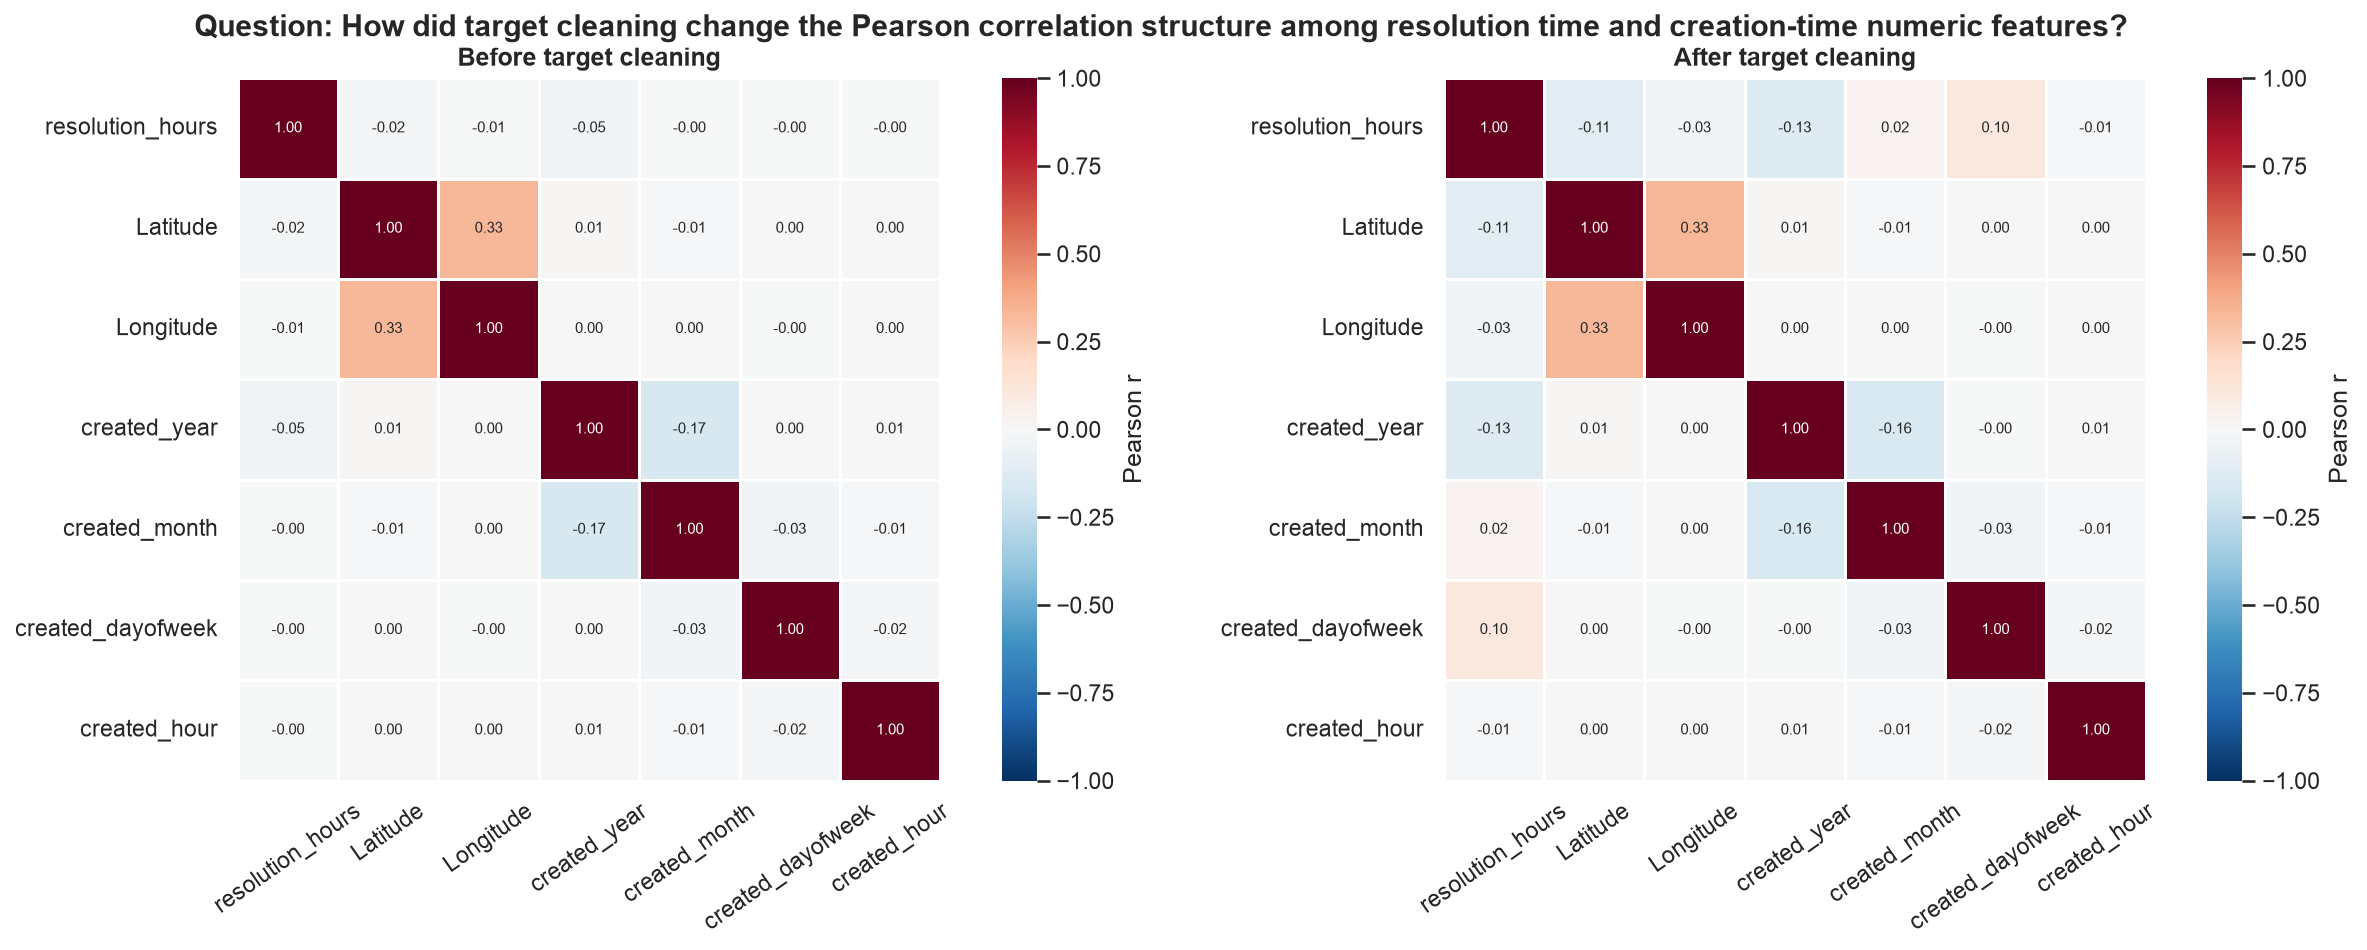

In [56]:
question = "Question: How did target cleaning change the Pearson correlation structure among resolution time and creation-time numeric features?"
corr_names = ["resolution_hours", "Latitude", "Longitude", "created_year", "created_month", "created_dayofweek", "created_hour"]

corr_before_frame = pd.DataFrame({
    "resolution_hours": heating["resolution_hours"],
    "Latitude": heating["Latitude"],
    "Longitude": heating["Longitude"],
    "created_year": heating["created_dt"].dt.year,
    "created_month": heating["created_dt"].dt.month,
    "created_dayofweek": heating["created_dt"].dt.dayofweek,
    "created_hour": heating["created_dt"].dt.hour,
})
corr_before = corr_before_frame[corr_names].corr(method="pearson")
corr_after = cleaned_modeling_df[corr_names].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150, constrained_layout=True)
for ax, matrix, subtitle in zip(axes, [corr_before, corr_after], ["Before target cleaning", "After target cleaning"]):
    sns.heatmap(matrix, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
                annot=True, fmt=".2f", annot_kws={"size": 7}, linewidths=0.5, linecolor="white",
                cbar_kws={"label": "Pearson r"})
    ax.set_title(subtitle)
    ax.tick_params(axis="x", rotation=35)
fig.suptitle(question, y=1.03, fontweight="semibold")
plt.show()

## 3. Predictor-focused EDA on the complete cleaned heating population

Each chart uses all retained rows. Category limits are chosen from full-data counts, and low-support geographic groups are excluded only from display to prevent unstable medians.

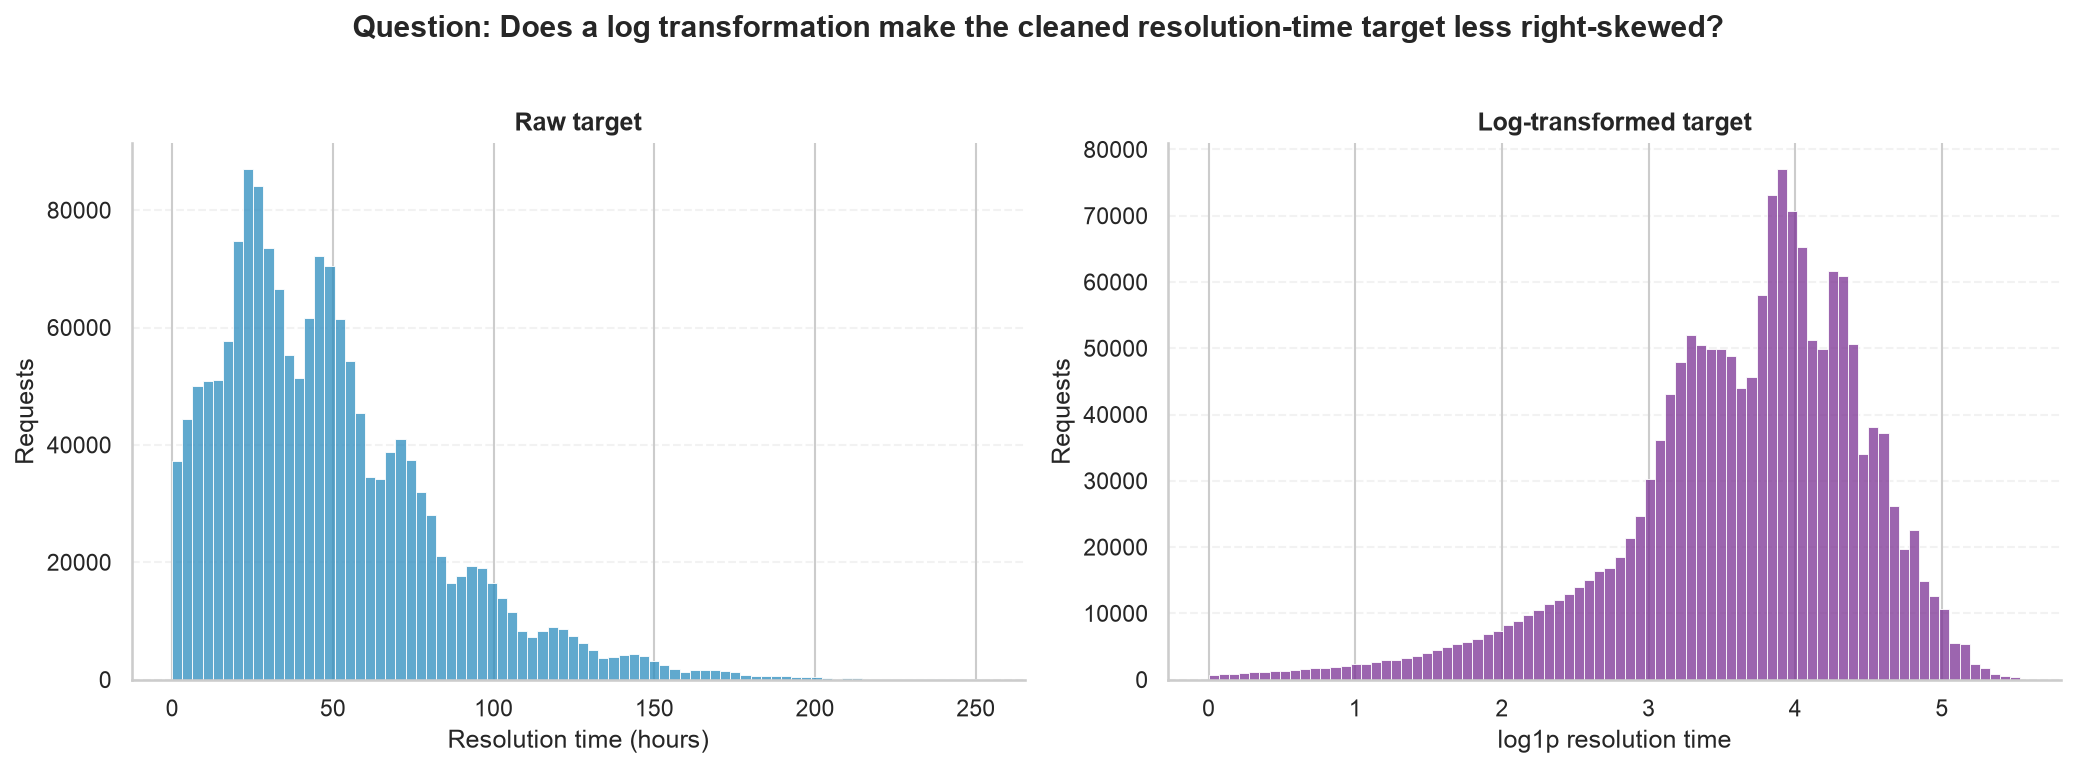

In [57]:
# Figure 1 of 9
question = "Question: Does a log transformation make the cleaned resolution-time target less right-skewed?"
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
sns.histplot(cleaned_modeling_df["resolution_hours"], bins=80, ax=axes[0], color="#2b8cbe", edgecolor="white")
sns.histplot(cleaned_modeling_df["log1p_resolution_hours"], bins=80, ax=axes[1], color="#7b3294", edgecolor="white")
axes[0].set(title="Raw target", xlabel="Resolution time (hours)", ylabel="Requests")
axes[1].set(title="Log-transformed target", xlabel="log1p resolution time", ylabel="Requests")
for ax in axes:
    ax.grid(axis="y", alpha=0.25, linestyle="--")
fig.suptitle(question, y=1.02, fontweight="semibold")
fig.tight_layout()
plt.show()

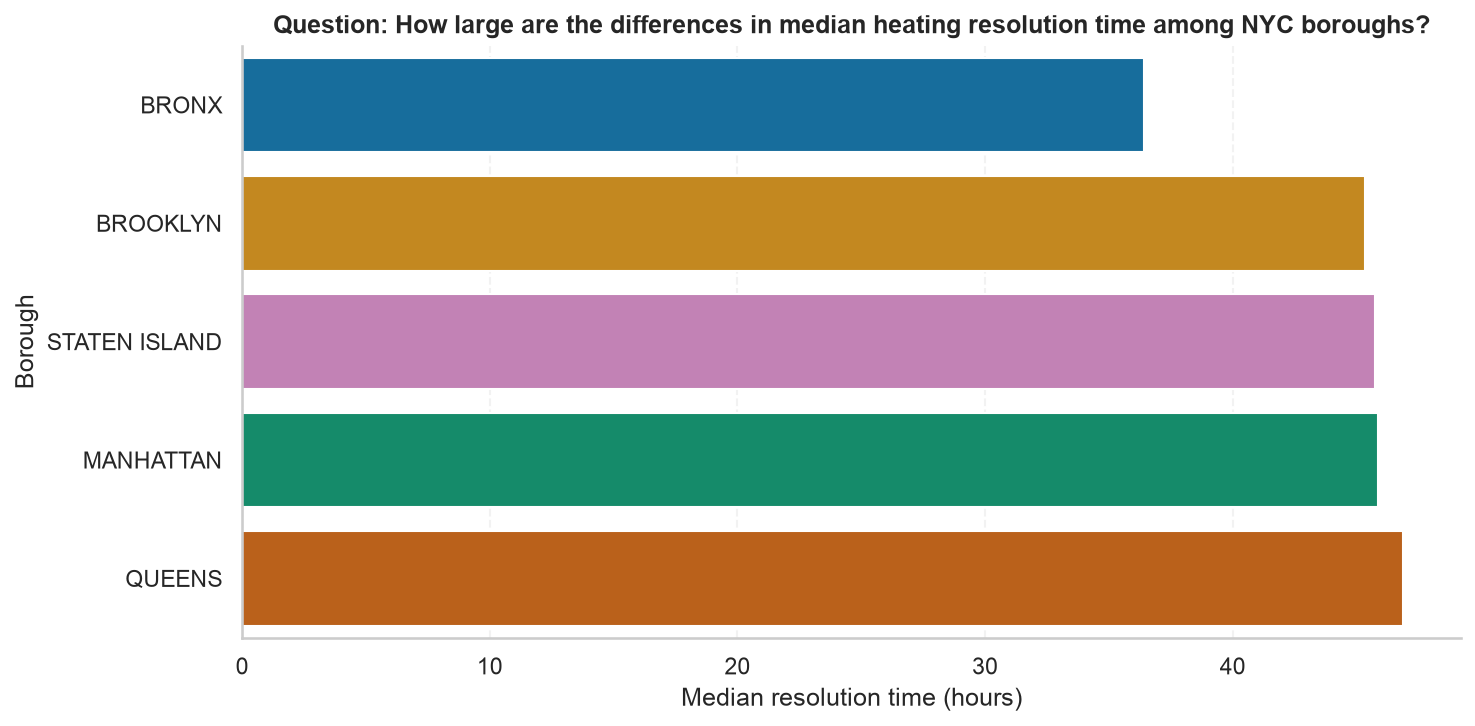

,requests,median_hours
Borough,,
BRONX,579092,36.43
BROOKLYN,440742,45.35
STATEN ISLAND,18293,45.76
MANHATTAN,376701,45.88
QUEENS,219030,46.87


In [58]:
# Figure 2 of 9
question = "Question: How large are the differences in median heating resolution time among NYC boroughs?"
borough_stats = cleaned_modeling_df.groupby(BOROUGH)["resolution_hours"].agg(requests="size", median_hours="median").sort_values("median_hours")
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
sns.barplot(data=borough_stats.reset_index(), x="median_hours", y=BOROUGH, order=borough_stats.index,
            hue=BOROUGH, palette=BOROUGH_COLORS, dodge=False, legend=False, ax=ax)
ax.set(title=question, xlabel="Median resolution time (hours)", ylabel="Borough")
ax.grid(axis="x", alpha=0.25, linestyle="--")
fig.tight_layout()
plt.show(); display(borough_stats.round(2))

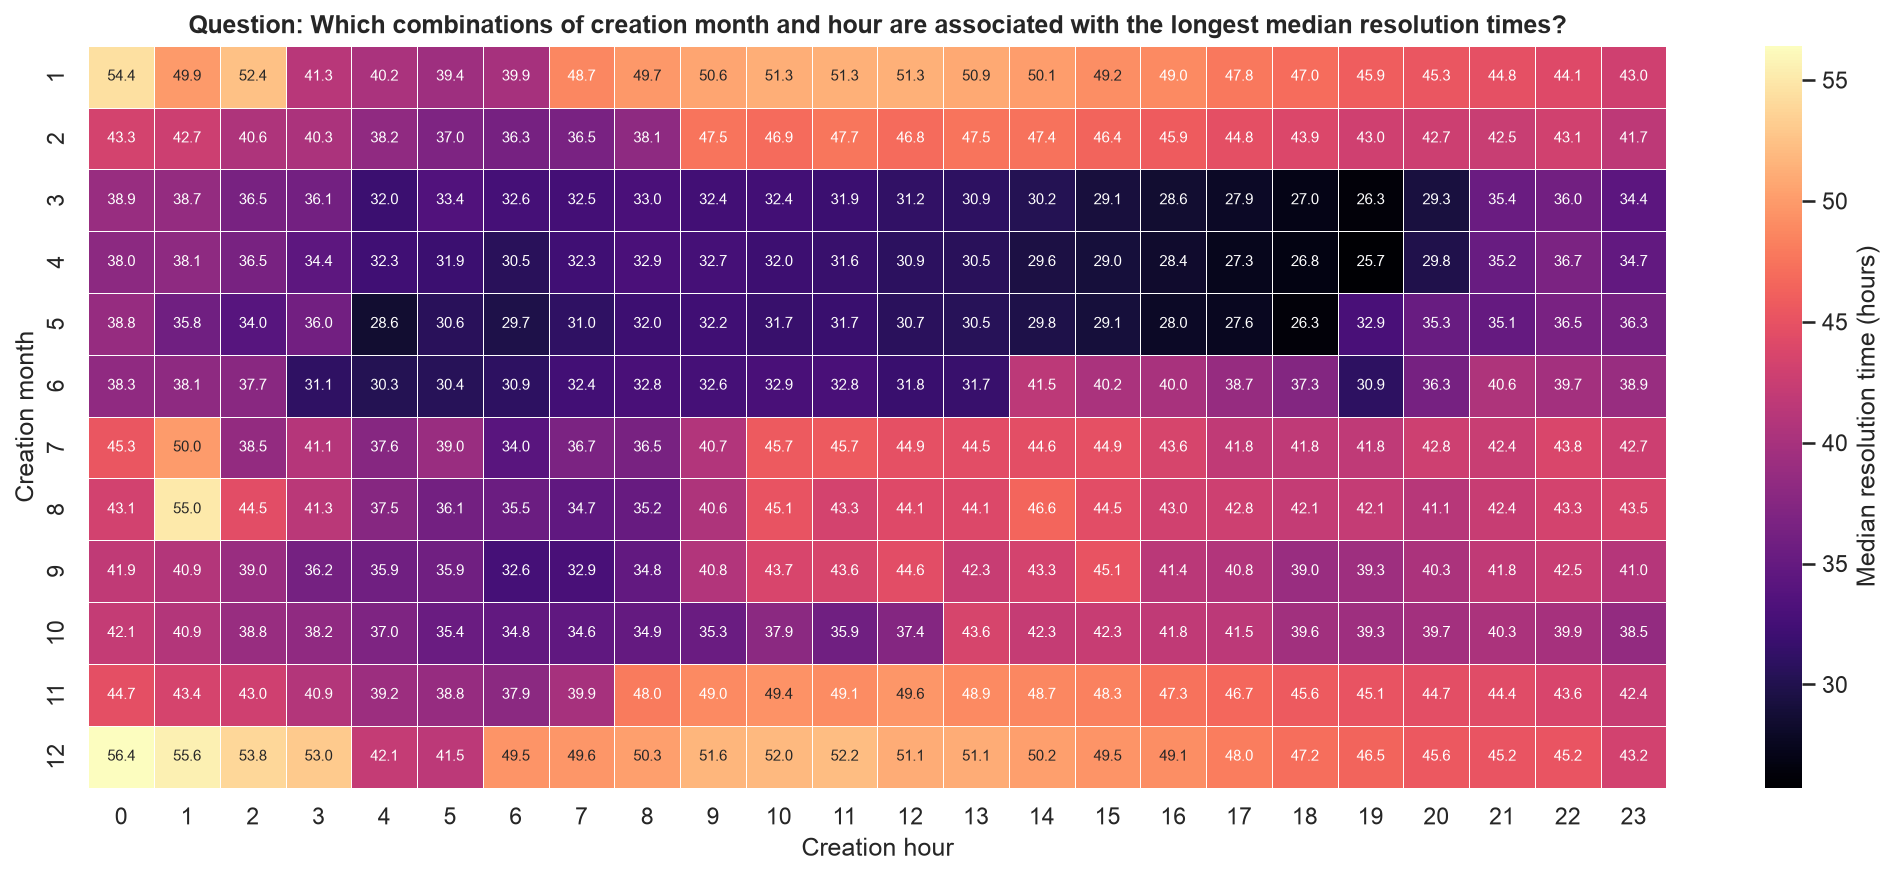

In [59]:
# Figure 3 of 9
question = "Question: Which combinations of creation month and hour are associated with the longest median resolution times?"
month_hour = cleaned_modeling_df.pivot_table(index="created_month", columns="created_hour", values="resolution_hours", aggfunc="median")
fig, ax = plt.subplots(figsize=(14, 6), dpi=150)
sns.heatmap(month_hour, ax=ax, cmap="magma", annot=True, fmt=".1f", annot_kws={"size": 7},
            linewidths=0.4, linecolor="white", cbar_kws={"label": "Median resolution time (hours)"})
ax.set(title=question, xlabel="Creation hour", ylabel="Creation month")
fig.tight_layout()
plt.show()

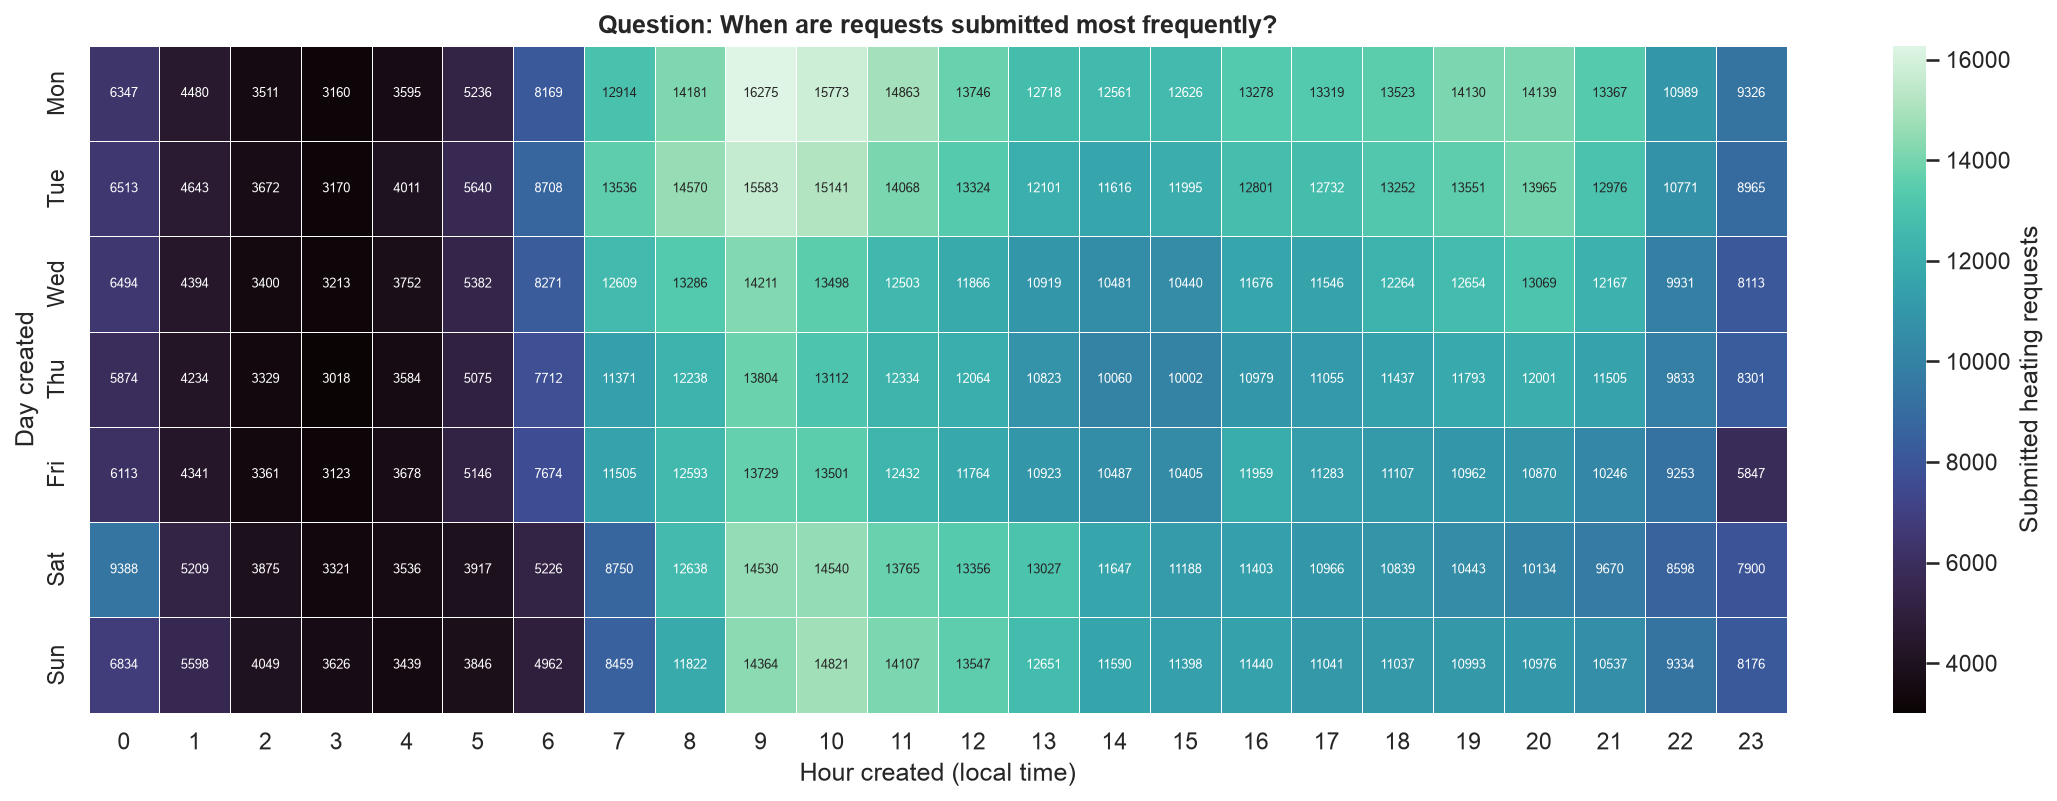

In [60]:
# Submission volume is measured before target filtering so open requests still count as submitted requests.
question = "Question: When are requests submitted most frequently?"
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
submission_timing = heating.dropna(subset=["created_dt"]).assign(
    created_dayofweek=lambda frame: frame["created_dt"].dt.dayofweek,
    created_hour=lambda frame: frame["created_dt"].dt.hour,
)
day_hour_requests = (
    submission_timing.groupby(["created_dayofweek", "created_hour"]).size()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24), fill_value=0)
)
day_hour_requests.index = weekday_names

fig, ax = plt.subplots(figsize=(15, 5.5), dpi=150)
sns.heatmap(day_hour_requests, ax=ax, cmap="mako", annot=True, fmt=".0f", annot_kws={"size": 6},
            linewidths=0.35, linecolor="white", cbar_kws={"label": "Submitted heating requests"})
ax.set(title=question, xlabel="Hour created (local time)", ylabel="Day created")
fig.tight_layout()
plt.show()

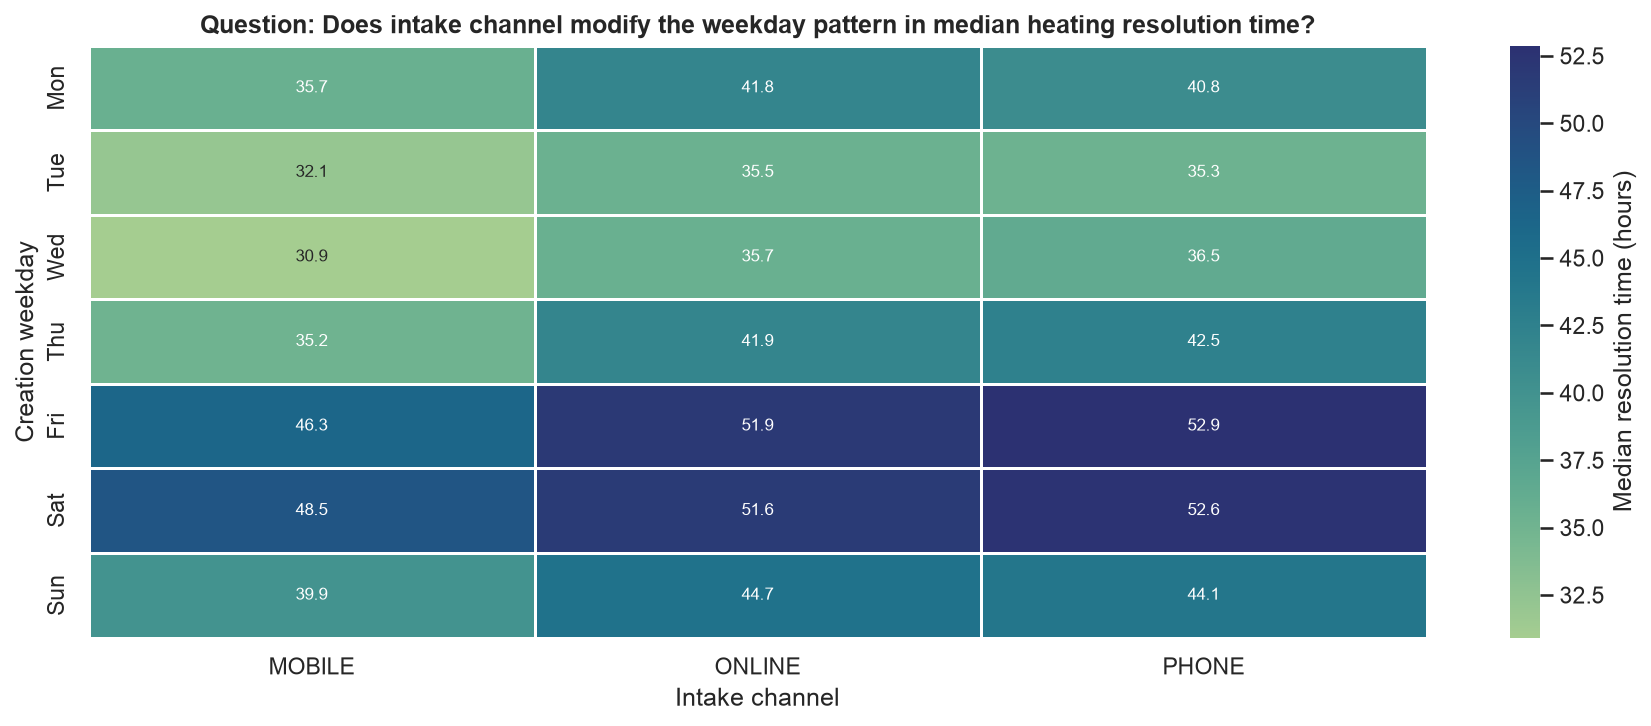

In [61]:
# Figure 4 of 9
question = "Question: Does intake channel modify the weekday pattern in median heating resolution time?"
weekday_channel = cleaned_modeling_df.pivot_table(index="created_dayofweek", columns="Open Data Channel Type", values="resolution_hours", aggfunc="median")
weekday_channel.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
sns.heatmap(weekday_channel, ax=ax, cmap="crest", annot=True, fmt=".1f", annot_kws={"size": 8},
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Median resolution time (hours)"})
ax.set(title=question, xlabel="Intake channel", ylabel="Creation weekday")
fig.tight_layout()
plt.show()

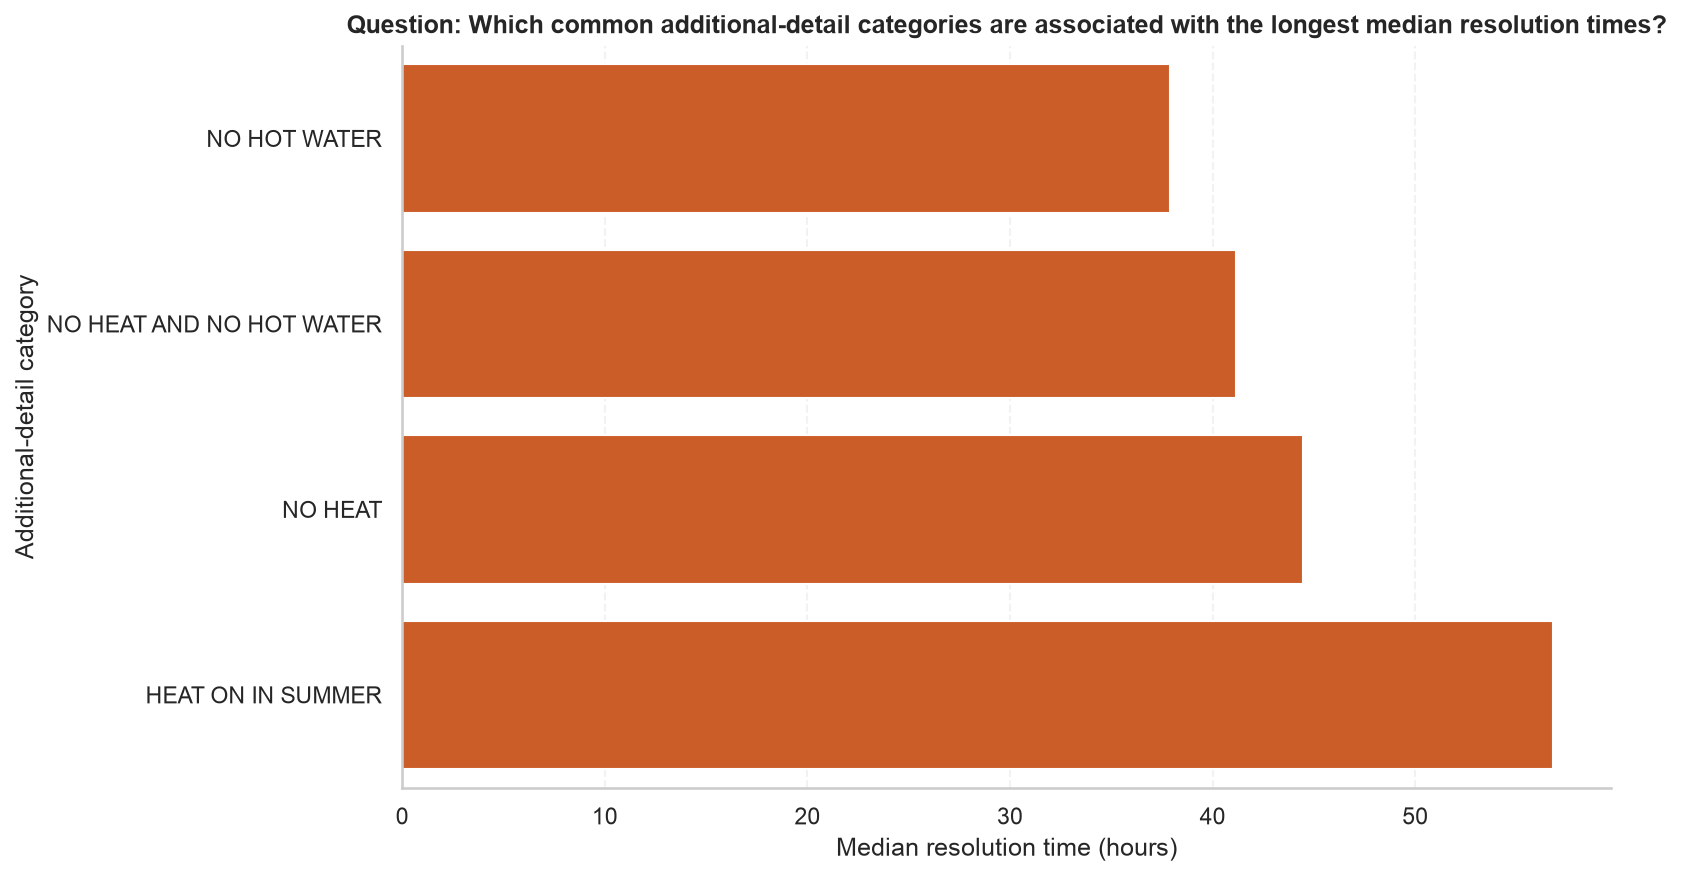

,requests,median_hours
Additional Details,,
NO HOT WATER,261406,37.88
NO HEAT AND NO HOT WATER,420202,41.13
NO HEAT,946749,44.44
HEAT ON IN SUMMER,5407,56.82
<NA>,101,57.57


In [62]:
# Figure 5 of 9
question = "Question: Which common additional-detail categories are associated with the longest median resolution times?"
top_additional = cleaned_modeling_df[ADDITIONAL].value_counts(dropna=False).head(12).index
additional_stats = (cleaned_modeling_df[cleaned_modeling_df[ADDITIONAL].isin(top_additional)]
                    .groupby(ADDITIONAL, dropna=False)["resolution_hours"]
                    .agg(requests="size", median_hours="median").sort_values("median_hours"))
fig, ax = plt.subplots(figsize=(11, 6), dpi=150)
sns.barplot(data=additional_stats.reset_index(), x="median_hours", y=ADDITIONAL,
            color="#e6550d", edgecolor="white", ax=ax)
ax.set(title=question, xlabel="Median resolution time (hours)", ylabel="Additional-detail category")
ax.grid(axis="x", alpha=0.25, linestyle="--")
fig.tight_layout()
plt.show(); display(additional_stats.round(2))

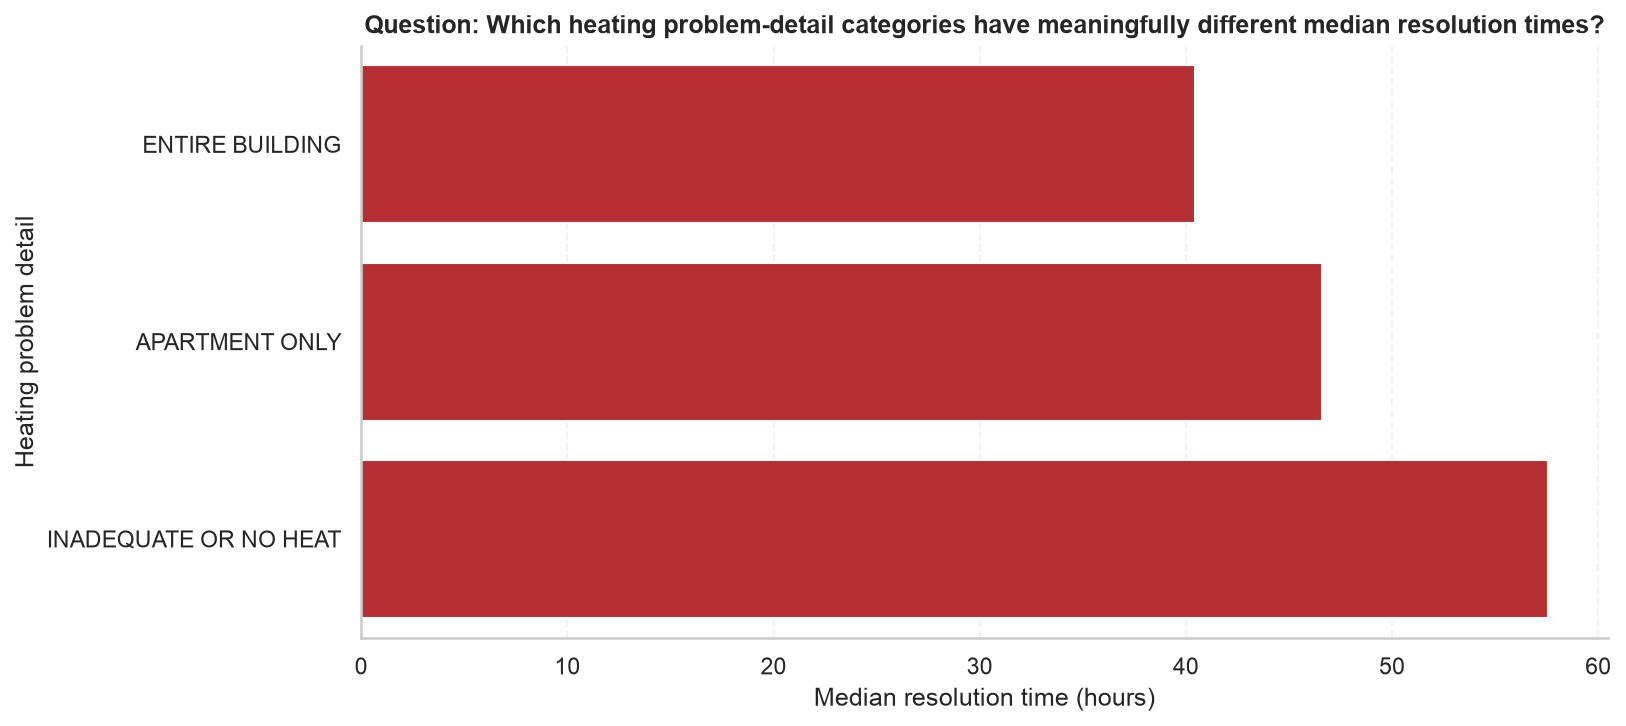

,requests,median_hours
Problem Detail (formerly Descriptor),,
ENTIRE BUILDING,1067803,40.42
APARTMENT ONLY,565961,46.62
INADEQUATE OR NO HEAT,101,57.57


In [63]:
# Figure 6 of 9
question = "Question: Which heating problem-detail categories have meaningfully different median resolution times?"
detail_stats = cleaned_modeling_df.groupby(DETAIL, dropna=False)["resolution_hours"].agg(requests="size", median_hours="median").sort_values("median_hours")
fig, ax = plt.subplots(figsize=(11, 5), dpi=150)
sns.barplot(data=detail_stats.reset_index(), x="median_hours", y=DETAIL,
            color="#cb181d", edgecolor="white", ax=ax)
ax.set(title=question, xlabel="Median resolution time (hours)", ylabel="Heating problem detail")
ax.grid(axis="x", alpha=0.25, linestyle="--")
fig.tight_layout()
plt.show(); display(detail_stats.round(2))

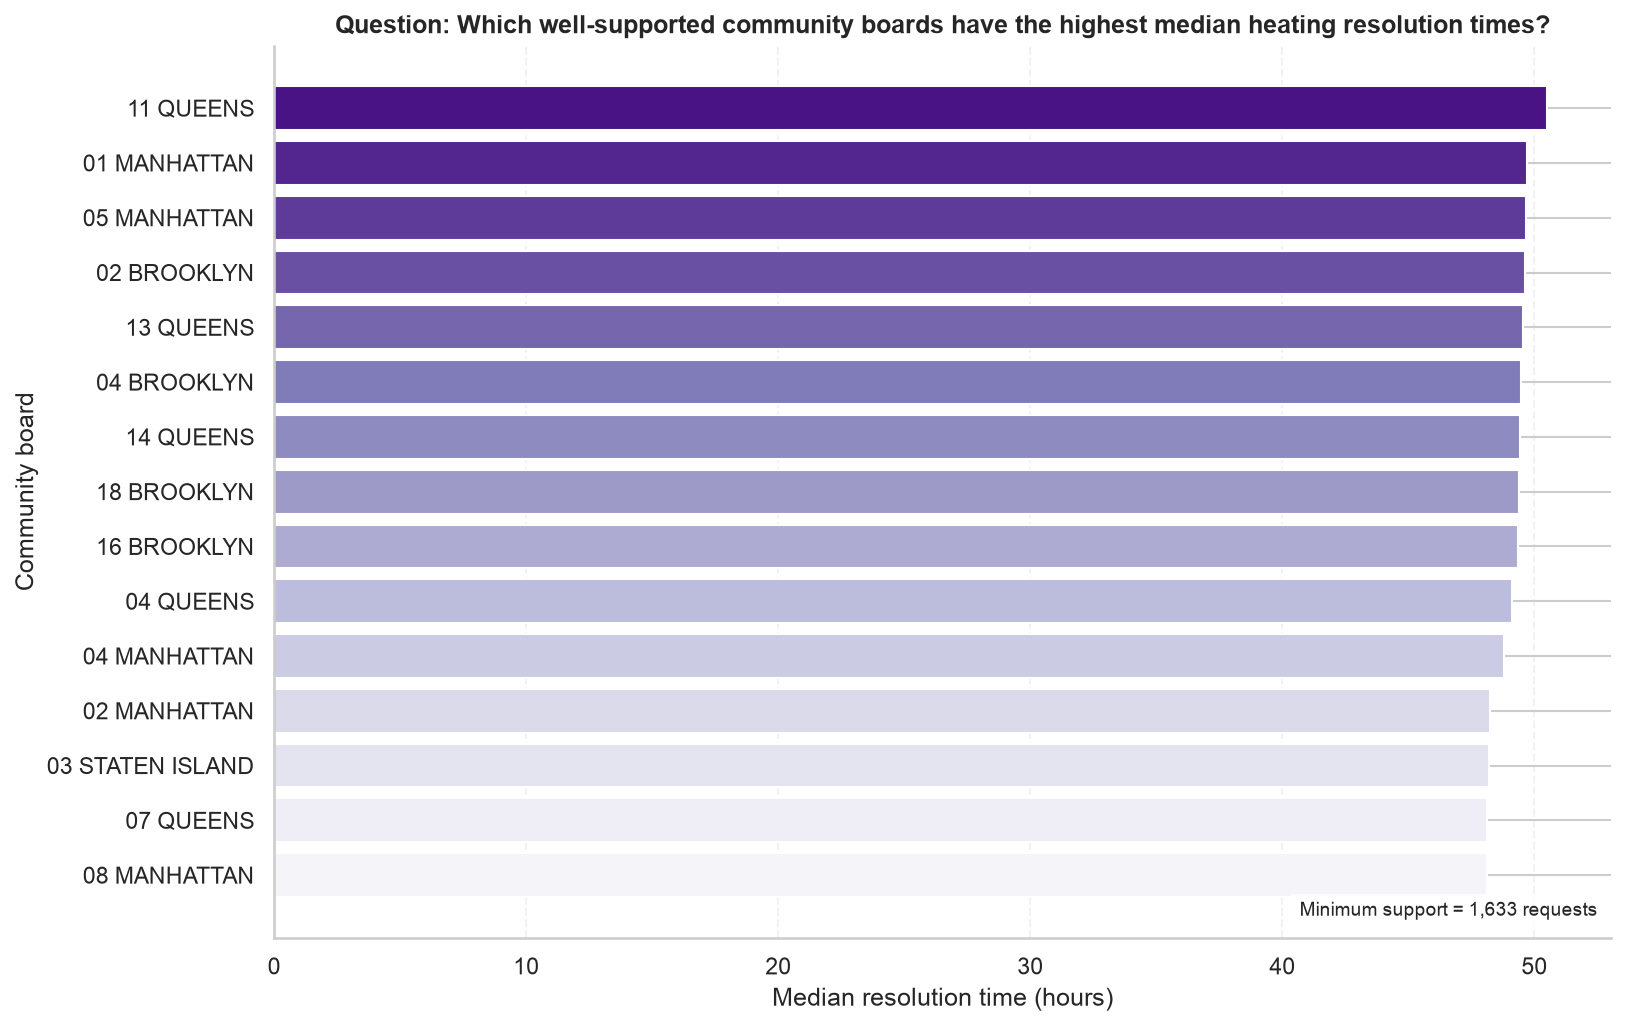

In [64]:
# Figure 7 of 9
question = "Question: Which well-supported community boards have the highest median heating resolution times?"
board_stats = cleaned_modeling_df.groupby("Community Board", dropna=False)["resolution_hours"].agg(requests="size", median_hours="median")
min_board_support = max(100, int(len(cleaned_modeling_df) * 0.001))
board_plot = board_stats[board_stats["requests"] >= min_board_support].nlargest(15, "median_hours").sort_values("median_hours")
fig, ax = plt.subplots(figsize=(11, 7), dpi=150)
ax.barh(board_plot.index.astype(str), board_plot["median_hours"], color=sns.color_palette("Purples", len(board_plot)), edgecolor="white")
ax.set(title=question, xlabel="Median resolution time (hours)", ylabel="Community board")
ax.grid(axis="x", alpha=0.25, linestyle="--")
ax.text(0.99, 0.02, f"Minimum support = {min_board_support:,} requests", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"})
fig.tight_layout()
plt.show()

In [65]:
# Figure 8 of 9
question = "Question: Among well-supported ZIP codes, is request volume associated with median resolution time?"
zip_stats = (
    cleaned_modeling_df.dropna(subset=["Incident Zip"])
    .groupby("Incident Zip", dropna=False)
    .agg(
        requests=("resolution_hours", "size"),
        median_hours=("resolution_hours", "median"),
        borough=(BOROUGH, lambda values: values.mode().iloc[0] if not values.mode().empty else "MISSING"),
    )
    .reset_index()
)
min_zip_support = max(100, int(len(cleaned_modeling_df) * 0.0005))
zip_plot = zip_stats[zip_stats["requests"] >= min_zip_support]
zip_spearman = zip_plot["requests"].corr(zip_plot["median_hours"], method="spearman")
fig = px.scatter(
    zip_plot,
    x="requests",
    y="median_hours",
    size="requests",
    color="borough",
    hover_name="Incident Zip",
    hover_data={"requests": ":,", "median_hours": ":.2f", "borough": True},
    size_max=32,
    opacity=0.75,
    labels={"requests": "Requests in ZIP code", "median_hours": "Median resolution time (hours)", "borough": "Borough"},
    title=question,
)
fig.add_annotation(
    x=0.01, y=0.99, xref="paper", yref="paper", showarrow=False,
    text=f"Spearman correlation = {zip_spearman:.2f}; minimum support = {min_zip_support:,} requests",
    bgcolor="rgba(255,255,255,0.8)", align="left",
)
fig.update_layout(template="plotly_white", legend_title_text="Borough")
fig.show()

In [66]:
# Figure 9 of 9
question = "Question: Where are the geographic clusters of unusually long median heating resolution times?"
geo = cleaned_modeling_df.dropna(subset=["Longitude", "Latitude", "resolution_hours"])
geo = geo[geo["Longitude"].between(-74.3, -73.65) & geo["Latitude"].between(40.45, 41.0)]

# Aggregate every valid row to an approximately 1-km grid before mapping; no sampling is used.
geo_grid = (
    geo.assign(
        latitude_grid=geo["Latitude"].round(2),
        longitude_grid=geo["Longitude"].round(2),
    )
    .groupby(["latitude_grid", "longitude_grid"], as_index=False)
    .agg(requests=("resolution_hours", "size"), median_hours=("resolution_hours", "median"))
)
min_grid_support = max(50, int(len(geo) * 0.0001))
geo_grid = geo_grid[geo_grid["requests"] >= min_grid_support]
fig = px.scatter_map(
    geo_grid,
    lat="latitude_grid",
    lon="longitude_grid",
    color="median_hours",
    size="requests",
    size_max=28,
    zoom=9.2,
    center={"lat": 40.7128, "lon": -74.0060},
    map_style="carto-positron",
    color_continuous_scale="Magma",
    hover_data={"requests": ":,", "median_hours": ":.2f", "latitude_grid": ":.2f", "longitude_grid": ":.2f"},
    labels={"median_hours": "Median resolution time (hours)", "requests": "Requests"},
    title=question,
)
fig.update_layout(
    template="plotly_white",
    margin={"r": 0, "t": 55, "l": 0, "b": 0},
)
fig.show()

### Additional course-driven Plotly analyses

These figures add QQ evidence for the target transformation, full-distribution comparisons rather than medians alone, uncertainty intervals for group estimates, and an ordered time-series view that follows the course line-style rules.

In [67]:
question = "Question: Does log1p transformation make heating resolution-time quantiles more consistent with a normal distribution?"
probabilities = np.linspace(0.001, 0.999, 999)
theoretical_q = stats.norm.ppf(probabilities)
raw_q = np.quantile(cleaned_modeling_df["resolution_hours"], probabilities)
log_q = np.quantile(cleaned_modeling_df["log1p_resolution_hours"], probabilities)

raw_fit = np.polyfit(theoretical_q, raw_q, 1)
log_fit = np.polyfit(theoretical_q, log_q, 1)
fig = make_subplots(rows=1, cols=2, subplot_titles=("Raw resolution hours", "log1p resolution hours"))
fig.add_trace(go.Scatter(x=theoretical_q, y=raw_q, mode="markers", marker={"size": 4, "opacity": 0.65, "color": "#2b8cbe"}, name="Raw quantiles"), row=1, col=1)
fig.add_trace(go.Scatter(x=theoretical_q, y=np.polyval(raw_fit, theoretical_q), mode="lines", line={"color": "#de2d26", "dash": "dash"}, name="Raw reference"), row=1, col=1)
fig.add_trace(go.Scatter(x=theoretical_q, y=log_q, mode="markers", marker={"size": 4, "opacity": 0.65, "color": "#7b3294"}, name="Log quantiles"), row=1, col=2)
fig.add_trace(go.Scatter(x=theoretical_q, y=np.polyval(log_fit, theoretical_q), mode="lines", line={"color": "#de2d26", "dash": "dash"}, name="Log reference"), row=1, col=2)
fig.update_xaxes(title_text="Theoretical normal quantiles")
fig.update_yaxes(title_text="Observed quantiles", row=1, col=1)
fig.update_layout(title=question, template=PLOT_TEMPLATE, height=520, legend_orientation="h")
fig.show()

In [68]:
question = "Question: How do heating resolution-time distributions differ across boroughs beyond their medians?"
quantile_probabilities = np.linspace(0.01, 0.99, 99)
borough_quantile_rows = []
for borough, values in cleaned_modeling_df.groupby(BOROUGH)["resolution_hours"]:
    quantiles = np.quantile(values.dropna(), quantile_probabilities)
    borough_quantile_rows.extend({
        BOROUGH: borough, "percentile": probability * 100, "resolution_hours": value
    } for probability, value in zip(quantile_probabilities, quantiles))
borough_quantiles = pd.DataFrame(borough_quantile_rows)
fig = px.line(
    borough_quantiles, x="percentile", y="resolution_hours", color=BOROUGH, line_dash=BOROUGH,
    labels={"percentile": "Percentile", "resolution_hours": "Resolution time (hours)"},
    title=question,
)
fig.update_traces(line={"width": LINE_WIDTH})
fig.update_layout(template=PLOT_TEMPLATE, hovermode="x unified", legend_title_text="Borough")
fig.show()

In [69]:
question = "Question: How precisely is the median heating resolution time estimated for each borough?"
borough_uncertainty_rows = []
for borough, values in cleaned_modeling_df.groupby(BOROUGH)["resolution_hours"]:
    ordered = np.sort(values.dropna().to_numpy())
    n_group = len(ordered)
    lower_index = max(0, int(stats.binom.ppf(0.025, n_group, 0.5)))
    upper_index = min(n_group - 1, int(stats.binom.ppf(0.975, n_group, 0.5)))
    median_value = float(np.median(ordered))
    borough_uncertainty_rows.append({
        BOROUGH: borough, "requests": n_group, "median_hours": median_value,
        "lower_95": float(ordered[lower_index]), "upper_95": float(ordered[upper_index]),
    })
borough_uncertainty = pd.DataFrame(borough_uncertainty_rows).sort_values("median_hours")
fig = px.scatter(
    borough_uncertainty, x="median_hours", y=BOROUGH, size="requests", color=BOROUGH,
    error_x=borough_uncertainty["upper_95"] - borough_uncertainty["median_hours"],
    error_x_minus=borough_uncertainty["median_hours"] - borough_uncertainty["lower_95"],
    hover_data={"requests": ":,", "median_hours": ":.2f", "lower_95": ":.2f", "upper_95": ":.2f"},
    labels={"median_hours": "Median resolution time (hours)"}, title=question, size_max=24,
)
fig.update_layout(template=PLOT_TEMPLATE, showlegend=False)
fig.show()

In [70]:
question = "Question: How has monthly median heating resolution time changed within each borough over the study period?"
monthly_borough = (
    cleaned_modeling_df.assign(created_month_start=cleaned_modeling_df["created_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby(["created_month_start", BOROUGH], as_index=False)
    .agg(requests=("resolution_hours", "size"), median_hours=("resolution_hours", "median"))
    .sort_values([BOROUGH, "created_month_start"])
)
fig = px.line(
    monthly_borough, x="created_month_start", y="median_hours", color=BOROUGH, line_dash=BOROUGH,
    markers=True, hover_data={"requests": ":,", "median_hours": ":.2f"},
    labels={"created_month_start": "Creation month", "median_hours": "Median resolution time (hours)"},
    title=question,
)
fig.update_traces(line={"width": LINE_WIDTH}, marker={"size": MARKER_SIZE})
fig.update_layout(template=PLOT_TEMPLATE, hovermode="x unified", legend_title_text="Borough")
fig.show()

## 4. Feature decisions, expanded predictor set, and three-column decision table

In [71]:
target_skew = cleaned_modeling_df["resolution_hours"].skew()
log_target_skew = cleaned_modeling_df["log1p_resolution_hours"].skew()

optional_high_cardinality = pd.DataFrame({
    "candidate": ["BBL", "Street Name", "Incident Address"],
    "use_now": ["Yes", "Yes", "No"],
    "recommended_handling": [
        "Categorical imputation plus rare-level pooling; CatBoost is an alternative.",
        "Categorical imputation plus rare-level pooling.",
        "Test later with hashing/CatBoost; do not one-hot raw addresses in the baseline.",
    ],
    "reason": [
        "Known at creation and may capture building-specific management history.",
        "Known at creation and can capture local building-stock and contractor patterns.",
        "Potentially predictive but near-unique, privacy-sensitive, and likely to overfit.",
    ],
})
display(optional_high_cardinality)

feature_inventory = pd.DataFrame({
    "feature": final_features,
    "type": ["numeric" if c in numeric_features else "categorical" for c in final_features],
    "missing_percent": [cleaned_modeling_df[c].isna().mean() * 100 for c in final_features],
    "distinct_nonmissing": [cleaned_modeling_df[c].nunique(dropna=True) for c in final_features],
})
display(feature_inventory)

,candidate,use_now,recommended_handling,reason
0,BBL,Yes,Categorical imputation plus rare-level pooling; CatBoost is an alternative.,Known at creation and may capture building-specific management history.
1,Street Name,Yes,Categorical imputation plus rare-level pooling.,Known at creation and can capture local building-stock and contractor patterns.
2,Incident Address,No,Test later with hashing/CatBoost; do not one-hot raw addresses in the baseline.,"Potentially predictive but near-unique, privacy-sensitive, and likely to overfit."


,feature,type,missing_percent,distinct_nonmissing
0,Latitude,numeric,0.011384,108798
1,Longitude,numeric,0.011384,108800
2,created_year,numeric,0.000000,7
3,created_month,numeric,0.000000,12
4,created_dayofweek,numeric,0.000000,7
5,created_hour,numeric,0.000000,24
6,is_weekend,numeric,0.000000,2
7,heating_season,numeric,0.000000,2
8,days_since_2020,numeric,0.000000,1556819
9,month_sin,numeric,0.000000,11


In [72]:
source_cols_physically_absent = sorted(set(header) - set(cleaned_modeling_df.columns))
leakage_dropped = [c for c in [CLOSED, STATUS, "Due Date", "Resolution Description", "Resolution Action Updated Date"] if c in header]
leakage_set = set(leakage_dropped)
copy_dropped = sorted(
    (set(exact_copy_drops + (["Location"] if location_match else [])) & set(source_cols_physically_absent))
    - leakage_set
)
constant_dropped = sorted(
    (set(constant_cols) & set(source_cols_physically_absent))
    - leakage_set - set(copy_dropped)
)
sparse_dropped = sorted(
    (set(sparse_cols) & set(source_cols_physically_absent))
    - leakage_set - set(copy_dropped) - set(constant_dropped)
)
unused_dropped = sorted(
    set(source_cols_physically_absent)
    - set(constant_dropped) - set(copy_dropped) - set(sparse_dropped) - leakage_set
    - {CREATED, "Unique Key"}
)

decision_rows = [
    {
        "Column / issue": "Placeholder strings",
        "Decision": "Convert exact placeholders to NaN before auditing missingness",
        "Because": f"{int(placeholder_audit['converted_to_NaN'].sum()) if len(placeholder_audit) else 0:,} placeholder values were found across {len(placeholder_audit):,} columns.",
    },
    {
        "Column / issue": "Unique Key and exact duplicate requests",
        "Decision": f"Exclude ID from comparison; drop {n_duplicates:,} duplicates and keep the first",
        "Because": "The ID is unique per row and otherwise hides duplicate request records.",
    },
    {
        "Column / issue": ", ".join(copy_dropped) or "No exact copy columns",
        "Decision": "Drop physically from the modeling DataFrame",
        "Because": "Exact/functional redundancy tests above show the same information is retained elsewhere.",
    },
    {
        "Column / issue": ", ".join(constant_dropped) or "No constant columns",
        "Decision": "Drop physically from the modeling DataFrame",
        "Because": "Each has one value after missing placeholders and case variants are normalized.",
    },
    {
        "Column / issue": ", ".join(sparse_dropped) or "No columns over the missingness threshold",
        "Decision": f"Drop columns with more than {MISSING_DROP_THRESHOLD:.0f}% missing",
        "Because": "The complete missing-value audit shows too little observed information for reliable imputation.",
    },
    {
        "Column / issue": ", ".join(leakage_dropped),
        "Decision": "Drop physically from predictors",
        "Because": "These outcomes and operational updates are not known at request creation.",
    },
    {
        "Column / issue": "Missing Closed Date / invalid or nonpositive target / extreme target",
        "Decision": "Drop rows using the mutually exclusive target audit",
        "Because": f"The target cannot be imputed; nonpositive hours are invalid; values above {upper_outlier_cutoff:,.2f} hours exceed raw p99.5.",
    },
    {
        "Column / issue": "Created Date",
        "Decision": "Derive trend, calendar, weekend, season, and cyclic time features; omit raw timestamp from X",
        "Because": "All derivatives are known at creation and represent nonlinear daily, weekly, seasonal, and long-term effects.",
    },
    {
        "Column / issue": ", ".join(numeric_features),
        "Decision": "Keep; median-impute with indicators and scale inside the training pipeline",
        "Because": "Known at creation; training-only median imputation is robust and prevents split leakage.",
    },
    {
        "Column / issue": ", ".join(categorical_features),
        "Decision": "Keep; impute a missing token and one-hot encode with rare-level pooling",
        "Because": "Known at creation and supported by predictor-focused EDA; rare/unseen levels are handled safely.",
    },
    {
        "Column / issue": ", ".join(unused_dropped),
        "Decision": "Drop physically from the cleaned modeling DataFrame",
        "Because": "Redundant representation, exact-address privacy/high-cardinality risk, near-constant state, or no distinct creation-time signal for the baseline.",
    },
    {
        "Column / issue": "resolution_hours",
        "Decision": "Train on log1p target and back-transform predictions",
        "Because": f"Target skew changes from {target_skew:.2f} to {log_target_skew:.2f} after log1p.",
    },
]
decision_table = pd.DataFrame(decision_rows, columns=["Column / issue", "Decision", "Because"])
display(decision_table)

,Column / issue,Decision,Because
0,Placeholder strings,Convert exact placeholders to NaN before auditing missingness,"1,665,415 placeholder values were found across 5 columns."
1,Unique Key and exact duplicate requests,"Exclude ID from comparison; drop 3,128 duplicates and keep the first",The ID is unique per row and otherwise hides duplicate request records.
2,"Intersection Street 1, Intersection Street 2, Location, Park Borough",Drop physically from the modeling DataFrame,Exact/functional redundancy tests above show the same information is retained elsewhere.
3,"Bridge Highway Direction, Bridge Highway Name, Bridge Highway Segment, Facility Type, Park Facility Name, Road Ramp, Taxi Company Borough, Taxi Pick Up Location, Vehicle Type",Drop physically from the modeling DataFrame,Each has one value after missing placeholders and case variants are normalized.
4,"Cross Street 1, Cross Street 2, Landmark",Drop columns with more than 30% missing,The complete missing-value audit shows too little observed information for reliable imputation.
5,"Closed Date, Status, Due Date, Resolution Description, Resolution Action Updated Date",Drop physically from predictors,These outcomes and operational updates are not known at request creation.
6,Missing Closed Date / invalid or nonpositive target / extreme target,Drop rows using the mutually exclusive target audit,The target cannot be imputed; nonpositive hours are invalid; values above 252.52 hours exceed raw p99.5.
7,Created Date,"Derive trend, calendar, weekend, season, and cyclic time features; omit raw timestamp from X","All derivatives are known at creation and represent nonlinear daily, weekly, seasonal, and long-term effects."
8,"Latitude, Longitude, created_year, created_month, created_dayofweek, created_hour, is_weekend, heating_season, days_since_2020, month_sin, month_cos, hour_sin, hour_cos, weekda...",Keep; median-impute with indicators and scale inside the training pipeline,Known at creation; training-only median imputation is robust and prevents split leakage.
9,"Problem Detail (formerly Descriptor), Additional Details, Borough, Incident Zip, City, Community Board, Council District, Police Precinct, Open Data Channel Type, Street Name, BBL",Keep; impute a missing token and one-hot encode with rare-level pooling,Known at creation and supported by predictor-focused EDA; rare/unseen levels are handled safely.


In [73]:
# Assertions make the decision table auditable against the executed transformations.
assert decision_table.columns.tolist() == ["Column / issue", "Decision", "Because"]
assert len(heating_raw) - n_duplicates == len(heating)
assert set(exact_copy_drops).isdisjoint(cleaned_modeling_df.columns)
assert set(sparse_cols).isdisjoint(cleaned_modeling_df.columns)
assert set(leakage_dropped).isdisjoint(cleaned_modeling_df.columns)
assert "Unique Key" not in cleaned_modeling_df
assert set(final_features).issubset(cleaned_modeling_df.columns)
assert cleaned_modeling_df.columns.tolist() == final_features + TARGET_COLUMNS + AUDIT_COLUMNS

audit_summary = pd.DataFrame({
    "check": ["source rows", "duplicates removed", "invalid/unlabeled/outlier rows removed", "final rows", "source columns", "final physical columns", "final predictors"],
    "value": [len(heating_raw), n_duplicates, int((row_reason != "kept").sum()), len(cleaned_modeling_df), len(header), cleaned_modeling_df.shape[1], len(final_features)],
})
display(audit_summary)

,check,value
0,source rows,1663150
1,duplicates removed,3128
2,invalid/unlabeled/outlier rows removed,26157
3,final rows,1633865
4,source columns,44
5,final physical columns,29
6,final predictors,26


## 5. Chronological splitting and unfitted leakage-safe preprocessing

In [74]:
model_frame = cleaned_modeling_df.sort_values("created_dt").reset_index(drop=True)
X = model_frame[final_features].copy()
y = model_frame["log1p_resolution_hours"].copy()

n = len(model_frame)
train_end, valid_end = int(n * 0.70), int(n * 0.85)
X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_valid, y_valid = X.iloc[train_end:valid_end], y.iloc[train_end:valid_end]
X_test, y_test = X.iloc[valid_end:], y.iloc[valid_end:]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(X_train), len(X_valid), len(X_test)],
    "start": [model_frame.iloc[:train_end]["created_dt"].min(), model_frame.iloc[train_end:valid_end]["created_dt"].min(), model_frame.iloc[valid_end:]["created_dt"].min()],
    "end": [model_frame.iloc[:train_end]["created_dt"].max(), model_frame.iloc[train_end:valid_end]["created_dt"].max(), model_frame.iloc[valid_end:]["created_dt"].max()],
})
display(split_summary)
assert split_summary.loc[0, "end"] <= split_summary.loc[1, "start"] <= split_summary.loc[1, "end"] <= split_summary.loc[2, "start"]

,split,rows,start,end
0,train,1143705,2020-01-01 00:04:45,2025-01-12 13:04:22
1,validation,245080,2025-01-12 13:04:25,2025-12-09 19:29:07
2,test,245080,2025-12-09 19:31:42,2026-10-01 17:53:22


In [75]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler(with_mean=False)),
])
try:
    one_hot = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=100, sparse_output=True)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", min_frequency=100, sparse=True)
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
    ("onehot", one_hot),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
], remainder="drop", sparse_threshold=0.3)

# Deliberately unfitted: place this object inside each model pipeline and fit on X_train only.
print(preprocessor)
print("Fitted attributes:", [k for k in vars(preprocessor) if k.endswith("_")])

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median')),
                                                 ('scaler',
                                                  StandardScaler(with_mean=False))]),
                                 ['Latitude', 'Longitude', 'created_year',
                                  'created_month', 'created_dayofweek',
                                  'created_hour', 'is_weekend',
                                  'heating_season', 'days_since_2020',
                                  'month_sin', 'month_cos', 'hour_sin',
                                  'hour_cos...
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='__MISSING__',
                            

In [76]:
feature_text = "\n".join(f"- `{c}`" for c in final_features)
strategy = f"""
## 6. Final ML strategy

The final DataFrame supplied to machine learning is `X`, built only from `final_features`; `cleaned_modeling_df` is the auditable parent table containing those predictors, the target, and `created_dt` for chronological splitting.

Recommended models:

1. **Median dummy regressor** for the minimum acceptable benchmark.
2. **Ridge or Elastic Net** as a transparent sparse linear baseline.
3. **LightGBM or XGBoost** for nonlinear time-geography-request interactions and efficient training on the large population.
4. **CatBoost** as a particularly useful alternative for `BBL`, `Street Name`, and other categorical variables, provided fitting and encoding occur only within the training period.
5. **Random Forest or Extra Trees** as nonlinear benchmarks, with memory-aware subsampling only during tuning.

Evaluate MAE and median absolute error in hours after `np.expm1`, RMSLE, and subgroup MAE by borough, year, and heating season. Tune on train/validation only and report the untouched chronological test set once.

### Final predictors

{feature_text}
"""
display(Markdown(strategy))


## 6. Final ML strategy

The final DataFrame supplied to machine learning is `X`, built only from `final_features`; `cleaned_modeling_df` is the auditable parent table containing those predictors, the target, and `created_dt` for chronological splitting.

Recommended models:

1. **Median dummy regressor** for the minimum acceptable benchmark.
2. **Ridge or Elastic Net** as a transparent sparse linear baseline.
3. **LightGBM or XGBoost** for nonlinear time-geography-request interactions and efficient training on the large population.
4. **CatBoost** as a particularly useful alternative for `BBL`, `Street Name`, and other categorical variables, provided fitting and encoding occur only within the training period.
5. **Random Forest or Extra Trees** as nonlinear benchmarks, with memory-aware subsampling only during tuning.

Evaluate MAE and median absolute error in hours after `np.expm1`, RMSLE, and subgroup MAE by borough, year, and heating season. Tune on train/validation only and report the untouched chronological test set once.

### Final predictors

- `Latitude`
- `Longitude`
- `created_year`
- `created_month`
- `created_dayofweek`
- `created_hour`
- `is_weekend`
- `heating_season`
- `days_since_2020`
- `month_sin`
- `month_cos`
- `hour_sin`
- `hour_cos`
- `weekday_sin`
- `weekday_cos`
- `Problem Detail (formerly Descriptor)`
- `Additional Details`
- `Borough`
- `Incident Zip`
- `City`
- `Community Board`
- `Council District`
- `Police Precinct`
- `Open Data Channel Type`
- `Street Name`
- `BBL`


## Completion checklist

- [x] Full-file 500,000-row streaming analysis
- [x] Macro univariate, bivariate, and multivariate complaint EDA
- [x] Full heating extraction with all original columns
- [x] Placeholder-to-missing conversion
- [x] Exact duplicate audit excluding `Unique Key` and first-copy retention
- [x] Exact and functional redundancy tests, including `Park Borough` versus `Borough`
- [x] Complete before/after missingness tables and explicit 30% threshold
- [x] Auditable target construction, invalid-row removal, and extreme-value rule
- [x] Physical creation of the final cleaned modeling DataFrame
- [x] Expanded interactive Plotly suite covering cleaning, distributions, bivariate relationships, multivariate structure, uncertainty, and time trends
- [x] Course chart rules from both supplied EDA PDFs documented and applied
- [x] Expanded predictor inventory, including imputed building/location features
- [x] Three-column evidence-based decision table
- [x] Assertions connecting decisions to executed transformations
- [x] Chronological split and unfitted preprocessing pipeline